# Entrega 2 — Limpieza y preparación de datos (ETL)
**Trabajo Práctico Integrador · Ciencia de Datos 5K1 · UTN FRC · Grupo 11**
Docente: Ing. Marisa del Carmen Callejas · Dataset: *Uber and Lyft Dataset Boston, MA* (Kaggle)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Perez-Alvaro/uber-lyft-dataset/blob/main/Nueva%20Version/notebook_presentacion/notebook_graficos_entrega_2.ipynb)

Este notebook es el **soporte de la presentación oral** (sin diapositivas): cada sección tiene orador, tiempo y gráficos.
**Para ejecutarlo:** *Run All* (en Colab: *Entorno de ejecución → Ejecutar todas*). La primera vez descarga los datos del repositorio del grupo (unos 115 MB).

### Orden de la presentación (5 minutos · 50 s por integrante)
| Tiempo | Integrante | Legajo | Tema | Gráficos |
|:-:|---|:-:|---|:-:|
| 0:00 – 0:50 | Álvaro Pérez | 97986 | Apertura: el dataset, las dos preguntas y el resultado de la limpieza | Tabla resumen · 01 |
| 0:50 – 1:40 | Juan Ignacio Cremona | 95789 | Nulos: por qué se eliminó Taxi y no se imputó | 02 |
| 1:40 – 2:30 | Ignacio Gil | 407114 | Selección de columnas (57 → 27), hora UTC y variables nuevas | 03 – 04 |
| 2:30 – 3:20 | Federico Gon | 94470 | Copias, distancias imposibles y precios extremos | 05 – 06 |
| 3:20 – 4:10 | Sofía Medina | 88655 | Las dos variables a predecir: `price` y `has_surge` | 07 – 08 |
| 4:10 – 5:00 | Facundo Dagnino Dailly | 94307 | Qué explica el recargo, pautas para la Entrega 3 y cierre | 09 – 10 |

Los gráficos 11 a 18 están en el **anexo de respaldo**, con la respuesta a la pregunta que cada uno contesta. Al final están las preguntas probables de la defensa.

### Qué pide la consigna y dónde está
| Pedido | Dónde |
|---|---|
| Limpieza de mayor impacto, con criterio: **nulos y faltantes** | Sección 2 · gráfico 02 (días sin datos: gráfico 11) |
| **Valores extremos** | Sección 4 · gráficos 05 – 06 |
| **Selección de columnas** | Sección 3 · gráficos 03 – 04 |
| Gráficos **antes y después** | Tabla resumen y gráficos 01 – 04 |
| Dos variables a predecir | Sección 5 · gráficos 07 – 08 |
| Todos hablan y se respeta el tiempo | Tabla de arriba: 50 s cada uno |

---
## 0 · Preparación (ejecutar antes de presentar; no se muestra)
Carga las librerías y el estilo de los gráficos, descarga los datos si hace falta y rehace la limpieza para comprobar que da exactamente el dataset final.

In [1]:
# Librerías
import warnings, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, Rectangle
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore")
FIG = Path("graficos")        # acá se guardan los gráficos en PNG
FIG.mkdir(exist_ok=True)

In [2]:
# --- Estilo gráfico común ---
# Tipografía: Calibri (igual que el informe). Si no está instalada se usa la siguiente disponible.
for carpeta_fuentes in ["/Applications/Microsoft Word.app/Contents/Resources/DFonts", "C:/Windows/Fonts"]:
    p = Path(carpeta_fuentes)
    if p.exists():
        for f in list(p.glob("[Cc]alibri*.ttf")):
            font_manager.fontManager.addfont(str(f))
# Sin Calibri (por ejemplo, en Colab) se usa Carlito, una fuente libre con las mismas medidas; se descarga una sola vez.
if not any(f.name == "Calibri" for f in font_manager.fontManager.ttflist):
    carpeta = Path("datos/fuentes"); carpeta.mkdir(parents=True, exist_ok=True)
    for variante in ["Regular", "Bold", "Italic", "BoldItalic"]:
        ttf = carpeta / f"Carlito-{variante}.ttf"
        try:
            if not ttf.exists():
                urllib.request.urlretrieve(f"https://github.com/google/fonts/raw/main/ofl/carlito/Carlito-{variante}.ttf", ttf)
            font_manager.fontManager.addfont(str(ttf))
        except Exception:
            ttf.unlink(missing_ok=True)   # sin internet se usa la fuente por defecto
# Calibri trae mapas de bits para pantalla que a 100 dpi se dibujan en blanco (faltan textos de los ejes):
# el notebook muestra los gráficos a 200 dpi, igual que los PNG exportados.
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("retina")

C = {
    "uber": "#1d6996", "lyft": "#be6b2e",           # identidad de plataforma (validada CVD)
    "verde": "#12403a", "serie": "#2c6e5f",         # serie única neutral
    "tinta": "#16211f", "tinta2": "#44534f", "muted": "#77837f",
    "grilla": "#e3e8e6", "eje": "#c9d2cf", "gris": "#b9c1be", "crema": "#fbf2e8",
}
PLATAFORMA = {"Uber": C["uber"], "Lyft": C["lyft"]}
CMAP_TERRACOTA = LinearSegmentedColormap.from_list("terracota", ["#fbf2e8", "#f0c9a4", "#d98a52", "#be6b2e", "#7a3d14"])
CMAP_AZUL = LinearSegmentedColormap.from_list("azul", ["#eef4f9", "#b9d3e6", "#6fa3c9", "#1d6996", "#0d3a57"])
CMAP_DIVERGENTE = LinearSegmentedColormap.from_list("div", ["#1d6996", "#9fbfd6", "#f0efec", "#e3b08a", "#be6b2e"])

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 200, "savefig.bbox": "tight", "savefig.facecolor": "white",
    "font.family": "sans-serif", "font.sans-serif": ["Calibri", "Carlito", "Arial", "DejaVu Sans"],
    "font.size": 11, "axes.titlesize": 12.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": C["tinta"], "axes.labelcolor": C["tinta2"], "axes.labelsize": 11,
    "axes.edgecolor": C["eje"], "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["grilla"], "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.axisbelow": True, "xtick.color": C["eje"], "ytick.color": C["eje"],
    "xtick.labelcolor": C["tinta2"], "ytick.labelcolor": C["tinta2"], "legend.frameon": False,
    "lines.linewidth": 2.2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "axes.formatter.use_locale": False,
})

FIGURAS = []

def figura(ancho=10, alto=4.6, filas=1, cols=1, titulo=None, subtitulo=None, **kw):
    """Crea una figura con encabezado (título + subtítulo) alineado a la izquierda."""
    fig, axes = plt.subplots(filas, cols, figsize=(ancho, alto), layout="constrained", **kw)
    if titulo:
        cabecera = 0.78 if subtitulo else 0.48
        fig.get_layout_engine().set(rect=(0, 0, 1, 1 - cabecera / alto))
        fig.text(0.005, 1 - 0.08 / alto, titulo, ha="left", va="top", fontsize=15.5, fontweight="bold", color=C["tinta"])
        if subtitulo:
            fig.text(0.005, 1 - 0.43 / alto, subtitulo, ha="left", va="top", fontsize=11.2, color=C["tinta2"])
    return fig, axes

def guardar(fig, nombre):
    """Exporta la figura a figures/<nombre>.png y la muestra en el notebook."""
    ruta = FIG / f"{nombre}.png"
    fig.savefig(ruta)
    FIGURAS.append(ruta.name)
    plt.show()
    plt.close(fig)

def _redondear_barras(ax, rects, horizontal, radio_px=4):
    """Dibuja barras con el extremo de dato redondeado (4 px) y la base recta."""
    ax.figure.canvas.draw()
    inv = ax.transData.inverted()
    (x0, y0), (x1, y1) = inv.transform((0, 0)), inv.transform((1, 1))
    ux, uy = abs(x1 - x0), abs(y1 - y0)  # unidades de dato por píxel
    for (pos, val, ancho, color) in rects:
        if val <= 0:
            continue
        if horizontal:
            r_dato = min(radio_px * ux, abs(val))
            ax.add_patch(FancyBboxPatch((0, pos - ancho / 2), val, ancho,
                         boxstyle=f"round,pad=0,rounding_size={r_dato}", mutation_aspect=uy / ux,
                         linewidth=0, facecolor=color, zorder=3))
            ax.add_patch(Rectangle((0, pos - ancho / 2), min(r_dato * 1.05, val), ancho, linewidth=0, facecolor=color, zorder=3))
        else:
            r_dato = min(radio_px * ux, ancho / 2)
            ax.add_patch(FancyBboxPatch((pos - ancho / 2, 0), ancho, val,
                         boxstyle=f"round,pad=0,rounding_size={r_dato}", mutation_aspect=uy / ux,
                         linewidth=0, facecolor=color, zorder=3))
            ax.add_patch(Rectangle((pos - ancho / 2, 0), ancho, min(radio_px * uy * 1.05, val), linewidth=0, facecolor=color, zorder=3))

def barras_h(ax, etiquetas, valores, colores, fmt=lambda v: f"{v:,.0f}", ancho=0.62, xmax=None, etiquetar=True):
    """Barras horizontales finas, de arriba hacia abajo en el orden recibido, con valor en la punta."""
    n = len(valores)
    colores = colores if isinstance(colores, (list, tuple, np.ndarray, pd.Series)) else [colores] * n
    xmax = xmax or max(valores) * 1.16
    ax.set_xlim(0, xmax)
    ax.set_ylim(n - 0.4, -0.6)
    ax.set_yticks(range(n), etiquetas)
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", length=0)
    _redondear_barras(ax, [(i, v, ancho, c) for i, (v, c) in enumerate(zip(valores, colores))], horizontal=True)
    if etiquetar:
        for i, v in enumerate(valores):
            ax.text(v + xmax * 0.012, i, fmt(v), va="center", ha="left", fontsize=10, color=C["tinta2"])

def barras_v(ax, etiquetas, valores, colores, fmt=lambda v: f"{v:,.0f}", ancho=0.62, ymax=None, etiquetar=True, rot=0):
    """Columnas finas con el valor sobre la tapa."""
    n = len(valores)
    colores = colores if isinstance(colores, (list, tuple, np.ndarray, pd.Series)) else [colores] * n
    ymax = ymax or max(valores) * 1.16
    ax.set_ylim(0, ymax)
    ax.set_xlim(-0.6, n - 0.4)
    ax.set_xticks(range(n), etiquetas, rotation=rot)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="x", length=0)
    _redondear_barras(ax, [(i, v, ancho, c) for i, (v, c) in enumerate(zip(valores, colores))], horizontal=False)
    if etiquetar:
        for i, v in enumerate(valores):
            ax.text(i, v + ymax * 0.015, fmt(v), va="bottom", ha="center", fontsize=9.5, color=C["tinta2"])

def leyenda_plataformas(ax_o_fig, loc="upper right", **kw):
    from matplotlib.lines import Line2D
    h = [Line2D([0], [0], marker="s", linestyle="", markersize=9, color=PLATAFORMA[k], label=k) for k in ("Uber", "Lyft")]
    ax_o_fig.legend(handles=h, loc=loc, **kw)

def pct(v, dec=1):
    return f"{v:.{dec}f}%".replace(".", ",")

def miles(v):
    return f"{v:,.0f}".replace(",", ".")

In [3]:
# Datos: se usan los CSV de la carpeta datos/ y, si no están, se descargan del repositorio del grupo
DATOS = Path("datos"); DATOS.mkdir(exist_ok=True)
REPO = "https://github.com/Perez-Alvaro/uber-lyft-dataset/raw/main/"

def obtener(zip_url, csv_nombre):
    csv = DATOS / csv_nombre
    if not csv.exists():
        destino = DATOS / "descarga.zip"
        print(f"Descargando {csv_nombre} …")
        urllib.request.urlretrieve(zip_url, destino)
        with zipfile.ZipFile(destino) as z:
            z.extract(csv_nombre, DATOS)
        destino.unlink()
    return csv

raw = pd.read_csv(obtener(REPO + "dataset.zip", "rideshare_kaggle.csv"))                                   # dataset original
limpio = pd.read_csv(obtener(REPO + "Nueva%20Version/CSV%20Nueva%20Columna/dataset_nueva_columna.zip", "dataset_nueva_columna.csv"))  # dataset final
RAW_COLS = list(raw.columns)
print(f"Original: {raw.shape[0]:,} filas × {raw.shape[1]} columnas | Final: {limpio.shape[0]:,} filas × {limpio.shape[1]} columnas")

Original: 693,071 filas × 57 columnas | Final: 636,568 filas × 27 columnas


In [4]:
# Preparación común (las mismas transformaciones del notebook principal)
NULOS_ANTES = int(raw.isna().sum().sum())
DIAS = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
NIVELES = {"Shared": "Compartido", "UberPool": "Compartido", "Lyft": "Estándar", "UberX": "Estándar", "WAV": "Estándar",
           "Lyft XL": "XL", "UberXL": "XL", "Lux": "Premium", "Lux Black": "Black", "Black": "Black",
           "Lux Black XL": "Black XL", "Black SUV": "Black XL", "Taxi": "Taxi"}

utc = pd.to_datetime(raw["timestamp"], unit="s", utc=True)
local = utc.dt.tz_convert("America/New_York")           # el dataset viene en UTC: se pasa a hora de Boston
raw["hora_utc"] = utc.dt.floor("h").dt.tz_localize(None)
raw["date_local"] = local.dt.tz_localize(None).dt.normalize()
raw["hour_local"] = local.dt.hour
raw["day_of_week"] = local.dt.dayofweek
raw["is_raining"] = (raw["precipIntensity"] > 0).astype(int)
raw["service_tier"] = raw["name"].map(NIVELES)
raw["has_surge"] = (raw["surge_multiplier"] > 1).astype(int)

eda = raw[raw["price"].notna()].copy()                  # viajes con precio
lyft = raw[raw["cab_type"] == "Lyft"].copy()
lyft_s = lyft[lyft["name"] != "Shared"].copy()          # subconjunto de has_surge

# Limpieza aplicada (para contar lo eliminado en cada paso)
sin_taxi = raw[raw["name"] != "Taxi"]
clave = sin_taxi[RAW_COLS].drop(columns=["id", "datetime", "timestamp"]).assign(ts_seg=np.floor(sin_taxi["timestamp"]))
sin_copias = sin_taxi[~clave.duplicated()]
final = sin_copias[sin_copias["distance"] >= 0.1]
ELIM = {"Taxi sin precio": len(raw) - len(sin_taxi), "Copias de una cotización": len(sin_taxi) - len(sin_copias),
        "Distancias imposibles": len(sin_copias) - len(final)}
assert len(final) == len(limpio), "la limpieza no coincide con el dataset final"

# Coordenadas reales de las 12 zonas (fuente externa: OpenStreetMap / Nominatim)
ZONAS = {'Back Bay': (42.350707, -71.07973), 'Beacon Hill': (42.358708, -71.067829), 'Boston University': (42.350422, -71.103225),
         'Fenway': (42.348832, -71.097211), 'Financial District': (42.35643, -71.055719), 'Haymarket Square': (42.362094, -71.057926),
         'North End': (42.365097, -71.054495), 'North Station': (42.366299, -71.062162), 'Northeastern University': (42.335107, -71.089258),
         'South Station': (42.350766, -71.055462), 'Theatre District': (42.351383, -71.064133), 'West End': (42.363919, -71.063899)}
zonas = pd.DataFrame([(z, la, lo) for z, (la, lo) in ZONAS.items()], columns=["zone", "zone_lat", "zone_lon"])
zc = zonas.set_index("zone")
ETIQ_ZONAS = {"North Station": (0, 11, "center"), "North End": (10, 3, "left"), "West End": (-10, -4, "right"),
              "Haymarket Square": (10, -6, "left"), "Beacon Hill": (0, 11, "center"), "Financial District": (10, 2, "left"),
              "Theatre District": (0, -12, "center"), "South Station": (10, -5, "left"), "Back Bay": (0, 11, "center"),
              "Boston University": (0, 11, "center"), "Fenway": (0, -12, "center"), "Northeastern University": (0, -12, "center")}
CMAP_PUNTOS = LinearSegmentedColormap.from_list("terracota_puntos", ["#f2d6bd", "#e0a271", "#be6b2e", "#7a3d14"])

def haversine_millas(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 3958.8 * 2 * np.arcsin(np.sqrt(a))

print("Eliminado por paso:", {k: f"{v:,}" for k, v in ELIM.items()})

Eliminado por paso: {'Taxi sin precio': '55,095', 'Copias de una cotización': '1,060', 'Distancias imposibles': '348'}


---
## 1 · Apertura — Álvaro Pérez · 0:00 – 0:50
- **El dataset:** 693.071 cotizaciones de Uber y Lyft en 12 zonas de Boston, con 57 columnas (datos del viaje y el clima de esa hora), entre el 25/11 y el 18/12/2018.
- **Dos preguntas:** en la Entrega 1 era cuánto cuesta un viaje; la cátedra pidió sumar una segunda variable a predecir.

| | Objetivo 1 | Objetivo 2 (nuevo) |
|---|---|---|
| Variable | `price` | `has_surge` |
| Pregunta | ¿Cuánto cuesta el viaje? | ¿El viaje tiene recargo por demanda? |
| Tipo | Regresión | Clasificación (1 si `surge_multiplier` > 1) |
| Datos | Uber + Lyft · 636.568 viajes | Solo Lyft, sin Shared · 255.953 viajes |

- **Resultado de la limpieza (tabla y gráfico 01):** de 693.071 a 636.568 filas (se conserva el 91,8%), de 57 a 27 columnas y sin nulos.

In [5]:
# Resumen de la limpieza: dataset original (antes) vs. dataset final (después)
clave_raw = raw[RAW_COLS].drop(columns=["id", "datetime", "timestamp"]).assign(ts_seg=np.floor(raw["timestamp"]))
copias_antes, copias_despues = int(clave_raw.duplicated().sum()), int(clave_raw.loc[final.index].duplicated().sum())
cortas_antes, cortas_despues = int((raw["distance"] < 0.1).sum()), int((limpio["distance"] < 0.1).sum())
resumen = pd.DataFrame({
    "Antes": [miles(len(raw)), len(RAW_COLS), miles(NULOS_ANTES), miles(copias_antes), miles(cortas_antes), "UTC (Londres)"],
    "Después": [miles(len(limpio)), limpio.shape[1], miles(int(limpio.isna().sum().sum())), miles(copias_despues), miles(cortas_despues), "Boston (UTC − 5 h)"],
}, index=["Filas", "Columnas", "Valores nulos", "Copias de una cotización", "Distancias imposibles (< 0,1 mi)", "Hora"])
display(resumen)
print(f"Del original, {copias_antes - ELIM['Copias de una cotización']} copias y {cortas_antes - ELIM['Distancias imposibles']} distancias "
      f"imposibles eran de Taxi y salieron con él: por eso se eliminan {miles(ELIM['Copias de una cotización'])} y {ELIM['Distancias imposibles']}.")

,Antes,Después
Filas,693.071,636.568
Columnas,57,27
Valores nulos,55.095,0
Copias de una cotización,1.677,0
"Distancias imposibles (< 0,1 mi)",406,0
Hora,UTC (Londres),Boston (UTC − 5 h)


Del original, 617 copias y 58 distancias imposibles eran de Taxi y salieron con él: por eso se eliminan 1.060 y 348.


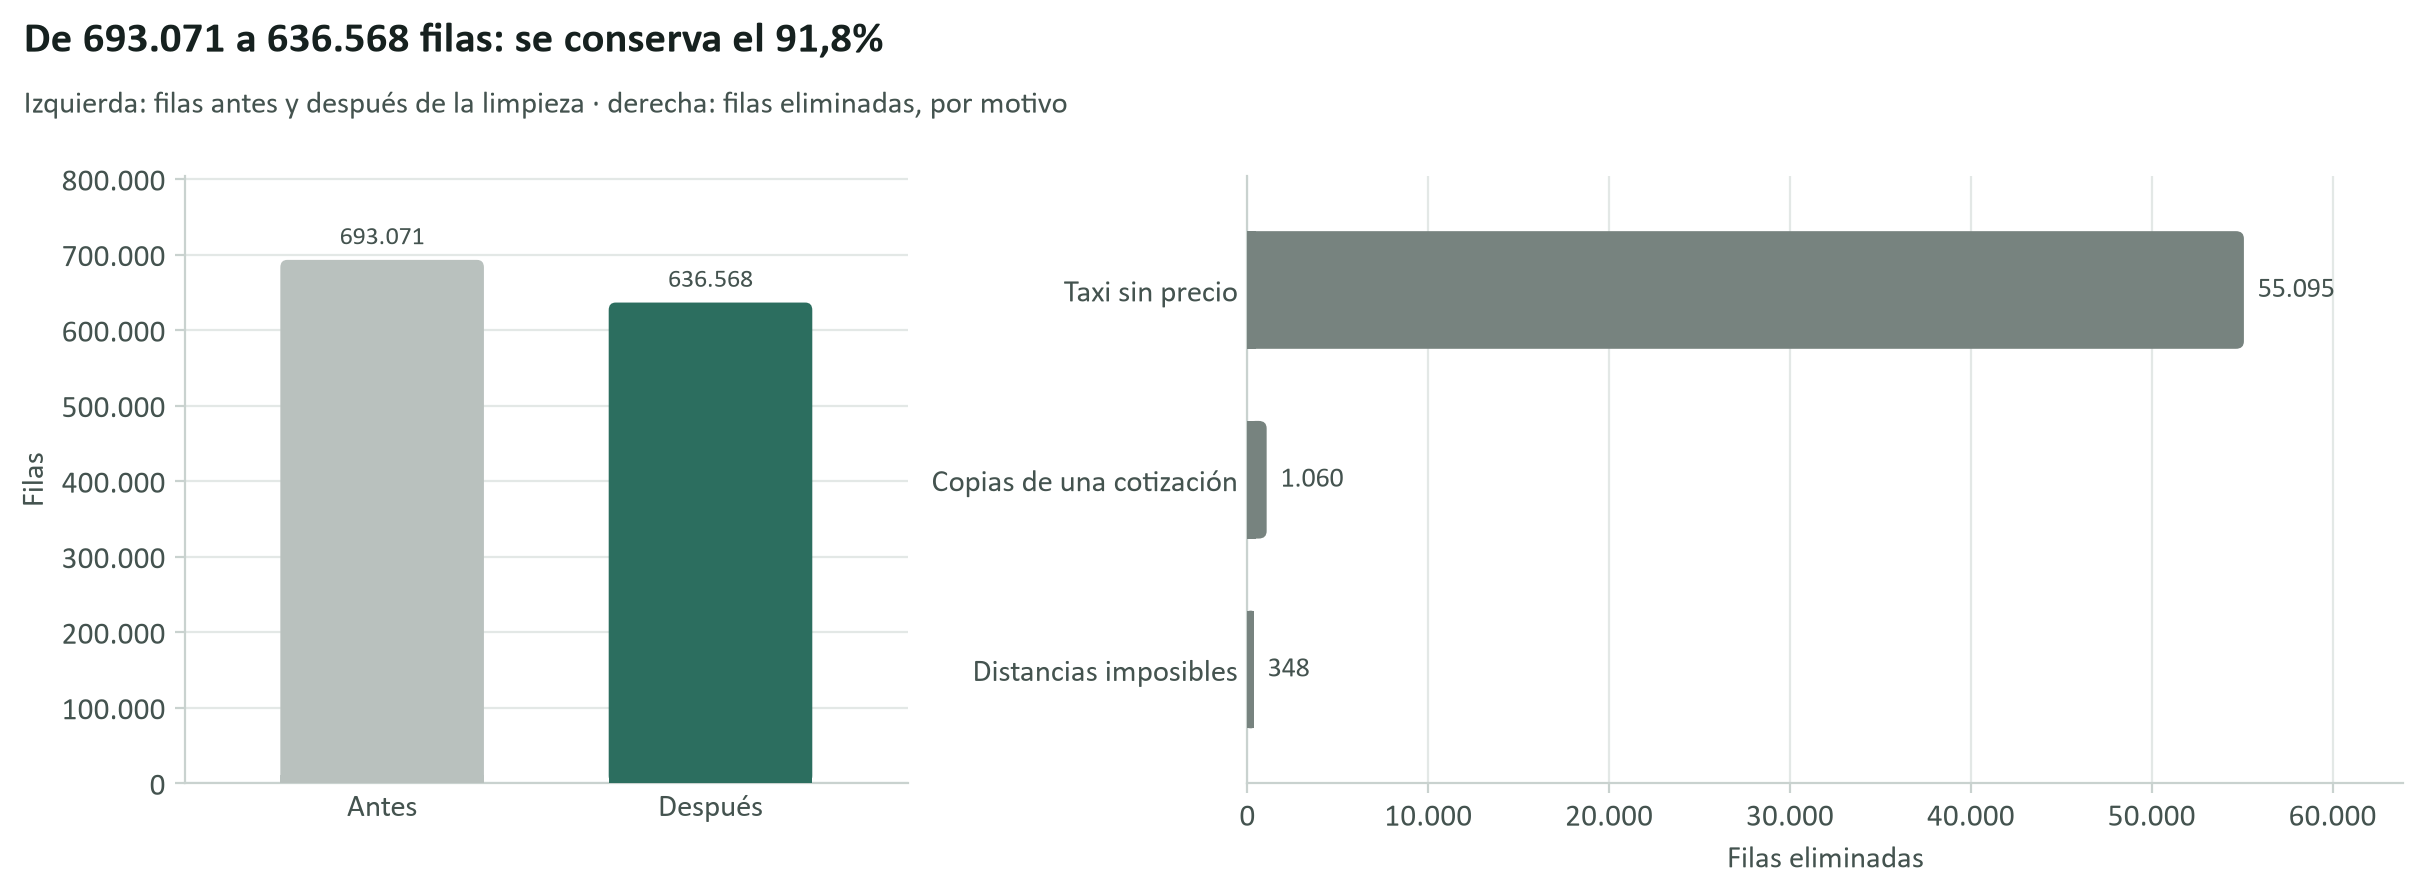

In [6]:
elim = pd.Series(ELIM)
pct_cons = 100 * len(limpio) / len(raw)
fig, (a1, a2) = figura(12, 4.4, 1, 2, titulo=f"De {miles(len(raw))} a {miles(len(limpio))} filas: se conserva el {pct(pct_cons)}",
                       subtitulo="Izquierda: filas antes y después de la limpieza · derecha: filas eliminadas, por motivo",
                       gridspec_kw={"width_ratios": [1, 1.6]})
barras_v(a1, ["Antes", "Después"], [len(raw), len(limpio)], [C["gris"], C["serie"]], fmt=miles)
a1.yaxis.set_major_formatter(lambda v, p: miles(v)); a1.set_ylabel("Filas")
barras_h(a2, elim.index.tolist(), elim.values, C["muted"], fmt=miles)
a2.set_xlabel("Filas eliminadas"); a2.xaxis.set_major_formatter(lambda v, p: miles(v))
guardar(fig, "01_filas_antes_despues")

---
## 2 · Nulos — Juan Ignacio Cremona · 0:50 – 1:40
- **Gráfico 02:** los 55.095 valores vacíos están todos en `price` y son el 100% de los viajes de **Taxi**. Ningún otro producto tiene nulos.
- **Decisión: eliminar Taxi, no imputar.** No hay ni un precio de Taxi en todo el dataset (Uber no lo cotiza por adelantado: se paga con taxímetro). Completarlo sería inventar la tarifa de un producto sin ninguna referencia.
- **Resultado:** el dataset queda sin nulos.

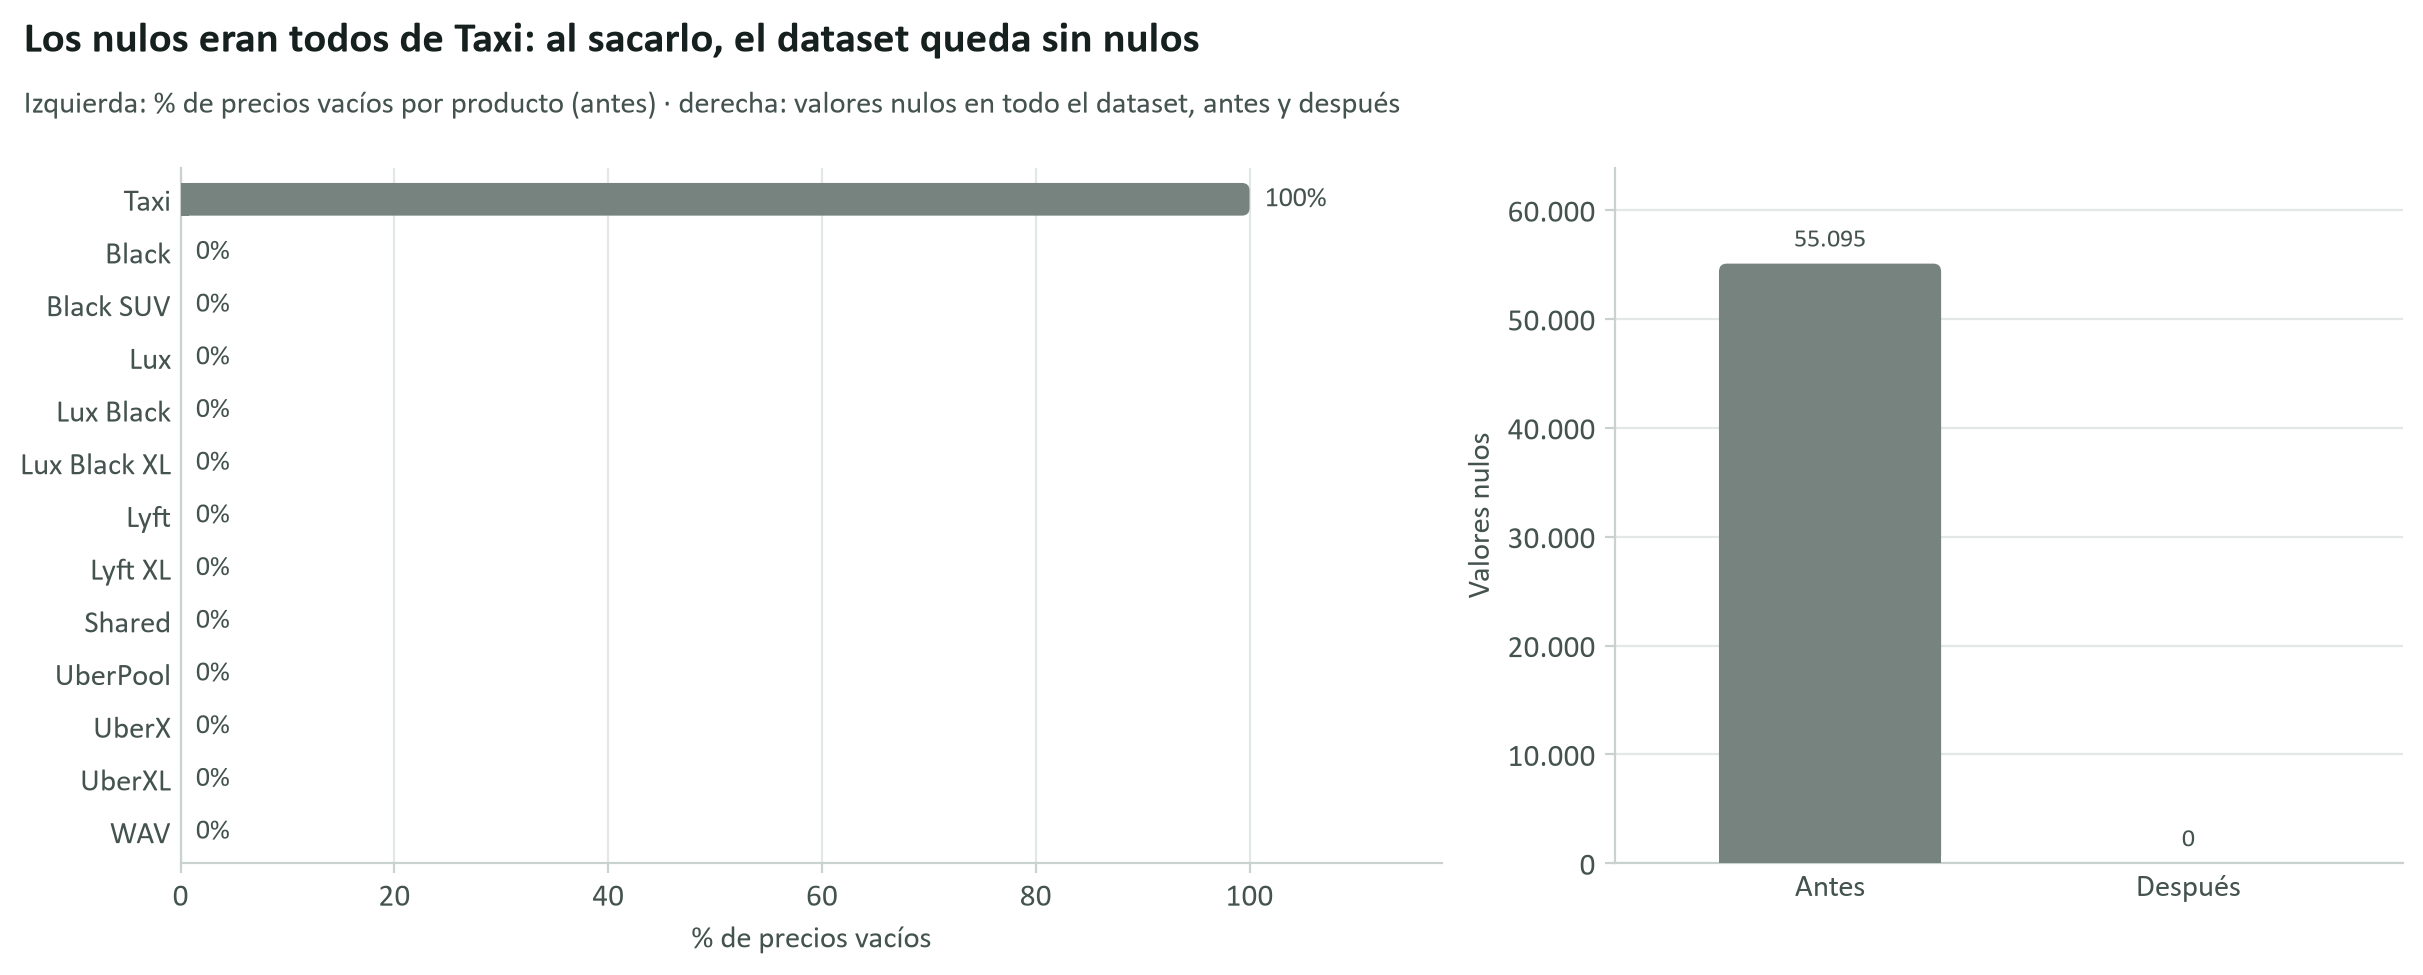

In [7]:
nul_prod = raw.assign(nulo=raw["price"].isna()).groupby("name")["nulo"].mean().mul(100).sort_values(ascending=False)
nulos_despues = int(limpio.isna().sum().sum())
fig, (a1, a2) = figura(12, 4.8, 1, 2, titulo="Los nulos eran todos de Taxi: al sacarlo, el dataset queda sin nulos",
                       subtitulo="Izquierda: % de precios vacíos por producto (antes) · derecha: valores nulos en todo el dataset, antes y después",
                       gridspec_kw={"width_ratios": [1.6, 1]})
barras_h(a1, nul_prod.index.tolist(), nul_prod.values, C["muted"], fmt=lambda v: pct(v, 0), xmax=118)
a1.set_xlabel("% de precios vacíos")
barras_v(a2, ["Antes", "Después"], [NULOS_ANTES, nulos_despues], [C["muted"], C["serie"]], fmt=miles)
a2.yaxis.set_major_formatter(lambda v, p: miles(v)); a2.set_ylabel("Valores nulos")
guardar(fig, "02_nulos_antes_despues")

---
## 3 · Selección de columnas — Ignacio Gil · 1:40 – 2:30
- **Criterio (gráfico 03):** sacar lo que repite información o no se relaciona con la tarifa. Salen 41: 31 de clima (máximos y mínimos del día y sus horarios, sensación térmica, ozono…), 6 de tiempo en UTC, 2 coordenadas del clima y 2 copias exactas (`visibility.1` es idéntica a `visibility`; `product_id` repite `name`).
- **Clima (gráfico 04):** había 80 pares de variables con correlación |r| > 0,85; entre las que quedan, la mayor es 0,68.
- **Hora:** el dataset está en UTC (hora de Londres), 5 horas adelantado respecto de Boston: se recalcula la hora local.
- **Se agregan 11 variables nuevas:**

| Variable | Cómo se crea |
|---|---|
| `datetime_local`, `hour_local` | `timestamp` (UTC) pasado a hora de Boston |
| `day_of_week`, `is_weekend` | Día de la semana (0 = lunes) y si es sábado o domingo |
| `time_slot` | Franja: madrugada, mañana, tarde o noche |
| `is_rush_hour` | Día hábil entre 7–9 h o 16–19 h |
| `is_dark` | Antes del amanecer o después del atardecer |
| `is_raining` | `precipIntensity` > 0 |
| `service_tier` | Nivel equivalente entre plataformas (Compartido, Estándar, XL, Premium, Black, Black XL) |
| `straight_line_miles` | Línea recta entre las zonas, con coordenadas de **OpenStreetMap** (fuente externa) |
| `has_surge` | 1 si `surge_multiplier` > 1 (**objetivo 2**) |

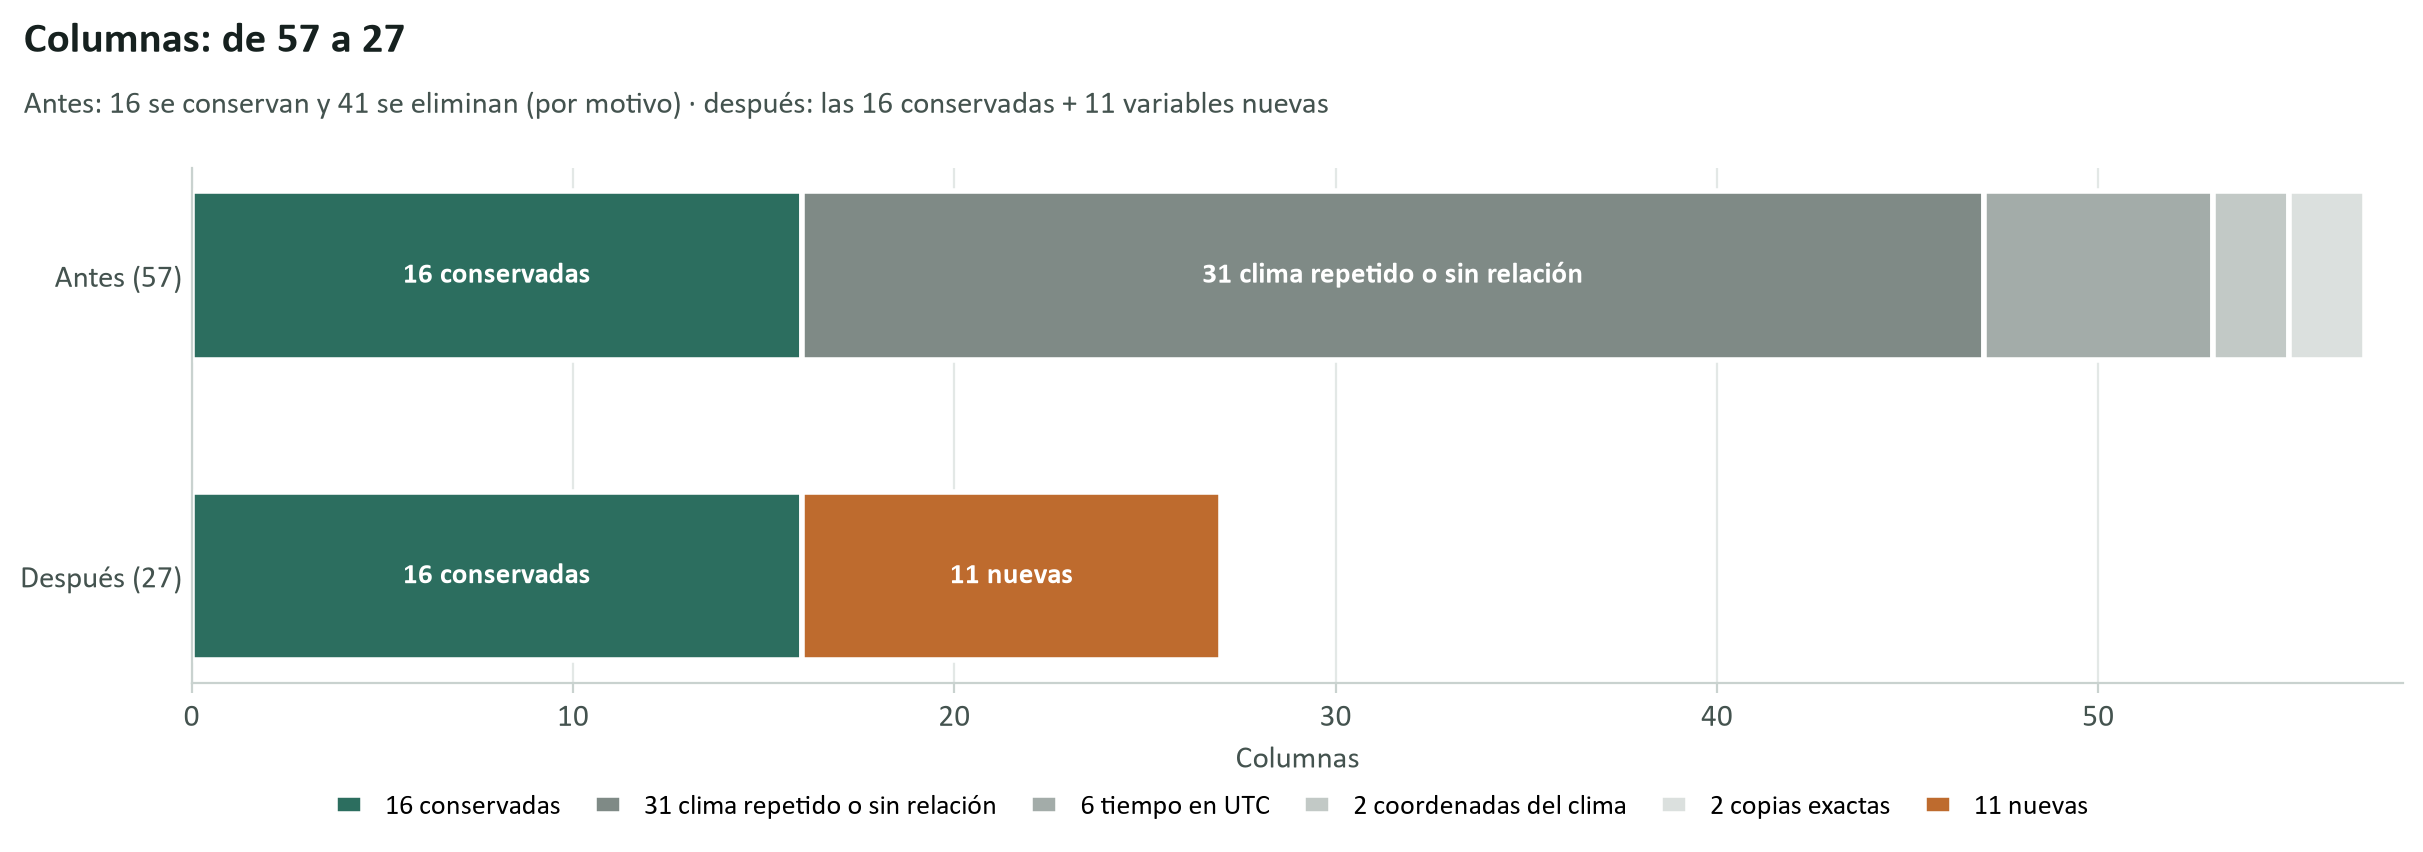

In [8]:
conservadas = [c for c in RAW_COLS if c in limpio.columns]
nuevas = [c for c in limpio.columns if c not in RAW_COLS]
tiempo, coords, copias = ["timestamp", "datetime", "hour", "day", "month", "timezone"], ["latitude", "longitude"], ["visibility.1", "product_id"]
clima_fuera = [c for c in RAW_COLS if c not in limpio.columns and c not in tiempo + coords + copias]
motivos = [("clima repetido o sin relación", len(clima_fuera)), ("tiempo en UTC", len(tiempo)),
           ("coordenadas del clima", len(coords)), ("copias exactas", len(copias))]
assert len(conservadas) + sum(n for _, n in motivos) == len(RAW_COLS) and len(conservadas) + len(nuevas) == limpio.shape[1]
grises = ["#7f8a86", "#a3aca9", "#c2c9c6", "#dbe0de"]
filas_col = [[("conservadas", len(conservadas), C["serie"])] + [(m, n, g) for (m, n), g in zip(motivos, grises)],
             [("conservadas", len(conservadas), C["serie"]), ("nuevas", len(nuevas), C["lyft"])]]
fig, ax = figura(12, 3.9, titulo=f"Columnas: de {len(RAW_COLS)} a {limpio.shape[1]}",
                 subtitulo=f"Antes: {len(conservadas)} se conservan y {len(RAW_COLS) - len(conservadas)} se eliminan (por motivo) · después: las {len(conservadas)} conservadas + {len(nuevas)} variables nuevas")
for fila, grupos in enumerate(filas_col):
    izq = 0
    for nombre, n, col in grupos:
        ax.barh(fila, n, left=izq, color=col, height=0.56, edgecolor="white", linewidth=2, label=f"{n} {nombre}" if fila == 0 or nombre == "nuevas" else None)
        if n >= 10:
            ax.text(izq + n / 2, fila, f"{n} {nombre}", ha="center", va="center", fontsize=10.5, fontweight="bold",
                    color="white" if col in (C["serie"], C["lyft"], grises[0]) else C["tinta"])
        izq += n
ax.set_yticks([0, 1], [f"Antes ({len(RAW_COLS)})", f"Después ({limpio.shape[1]})"])
ax.invert_yaxis(); ax.set_xlim(0, len(RAW_COLS) + 1); ax.set_xlabel("Columnas")
ax.grid(axis="y", visible=False); ax.tick_params(axis="y", length=0)
fig.legend(loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.08), fontsize=10, handlelength=1, columnspacing=1.2)
guardar(fig, "03_columnas_antes_despues")

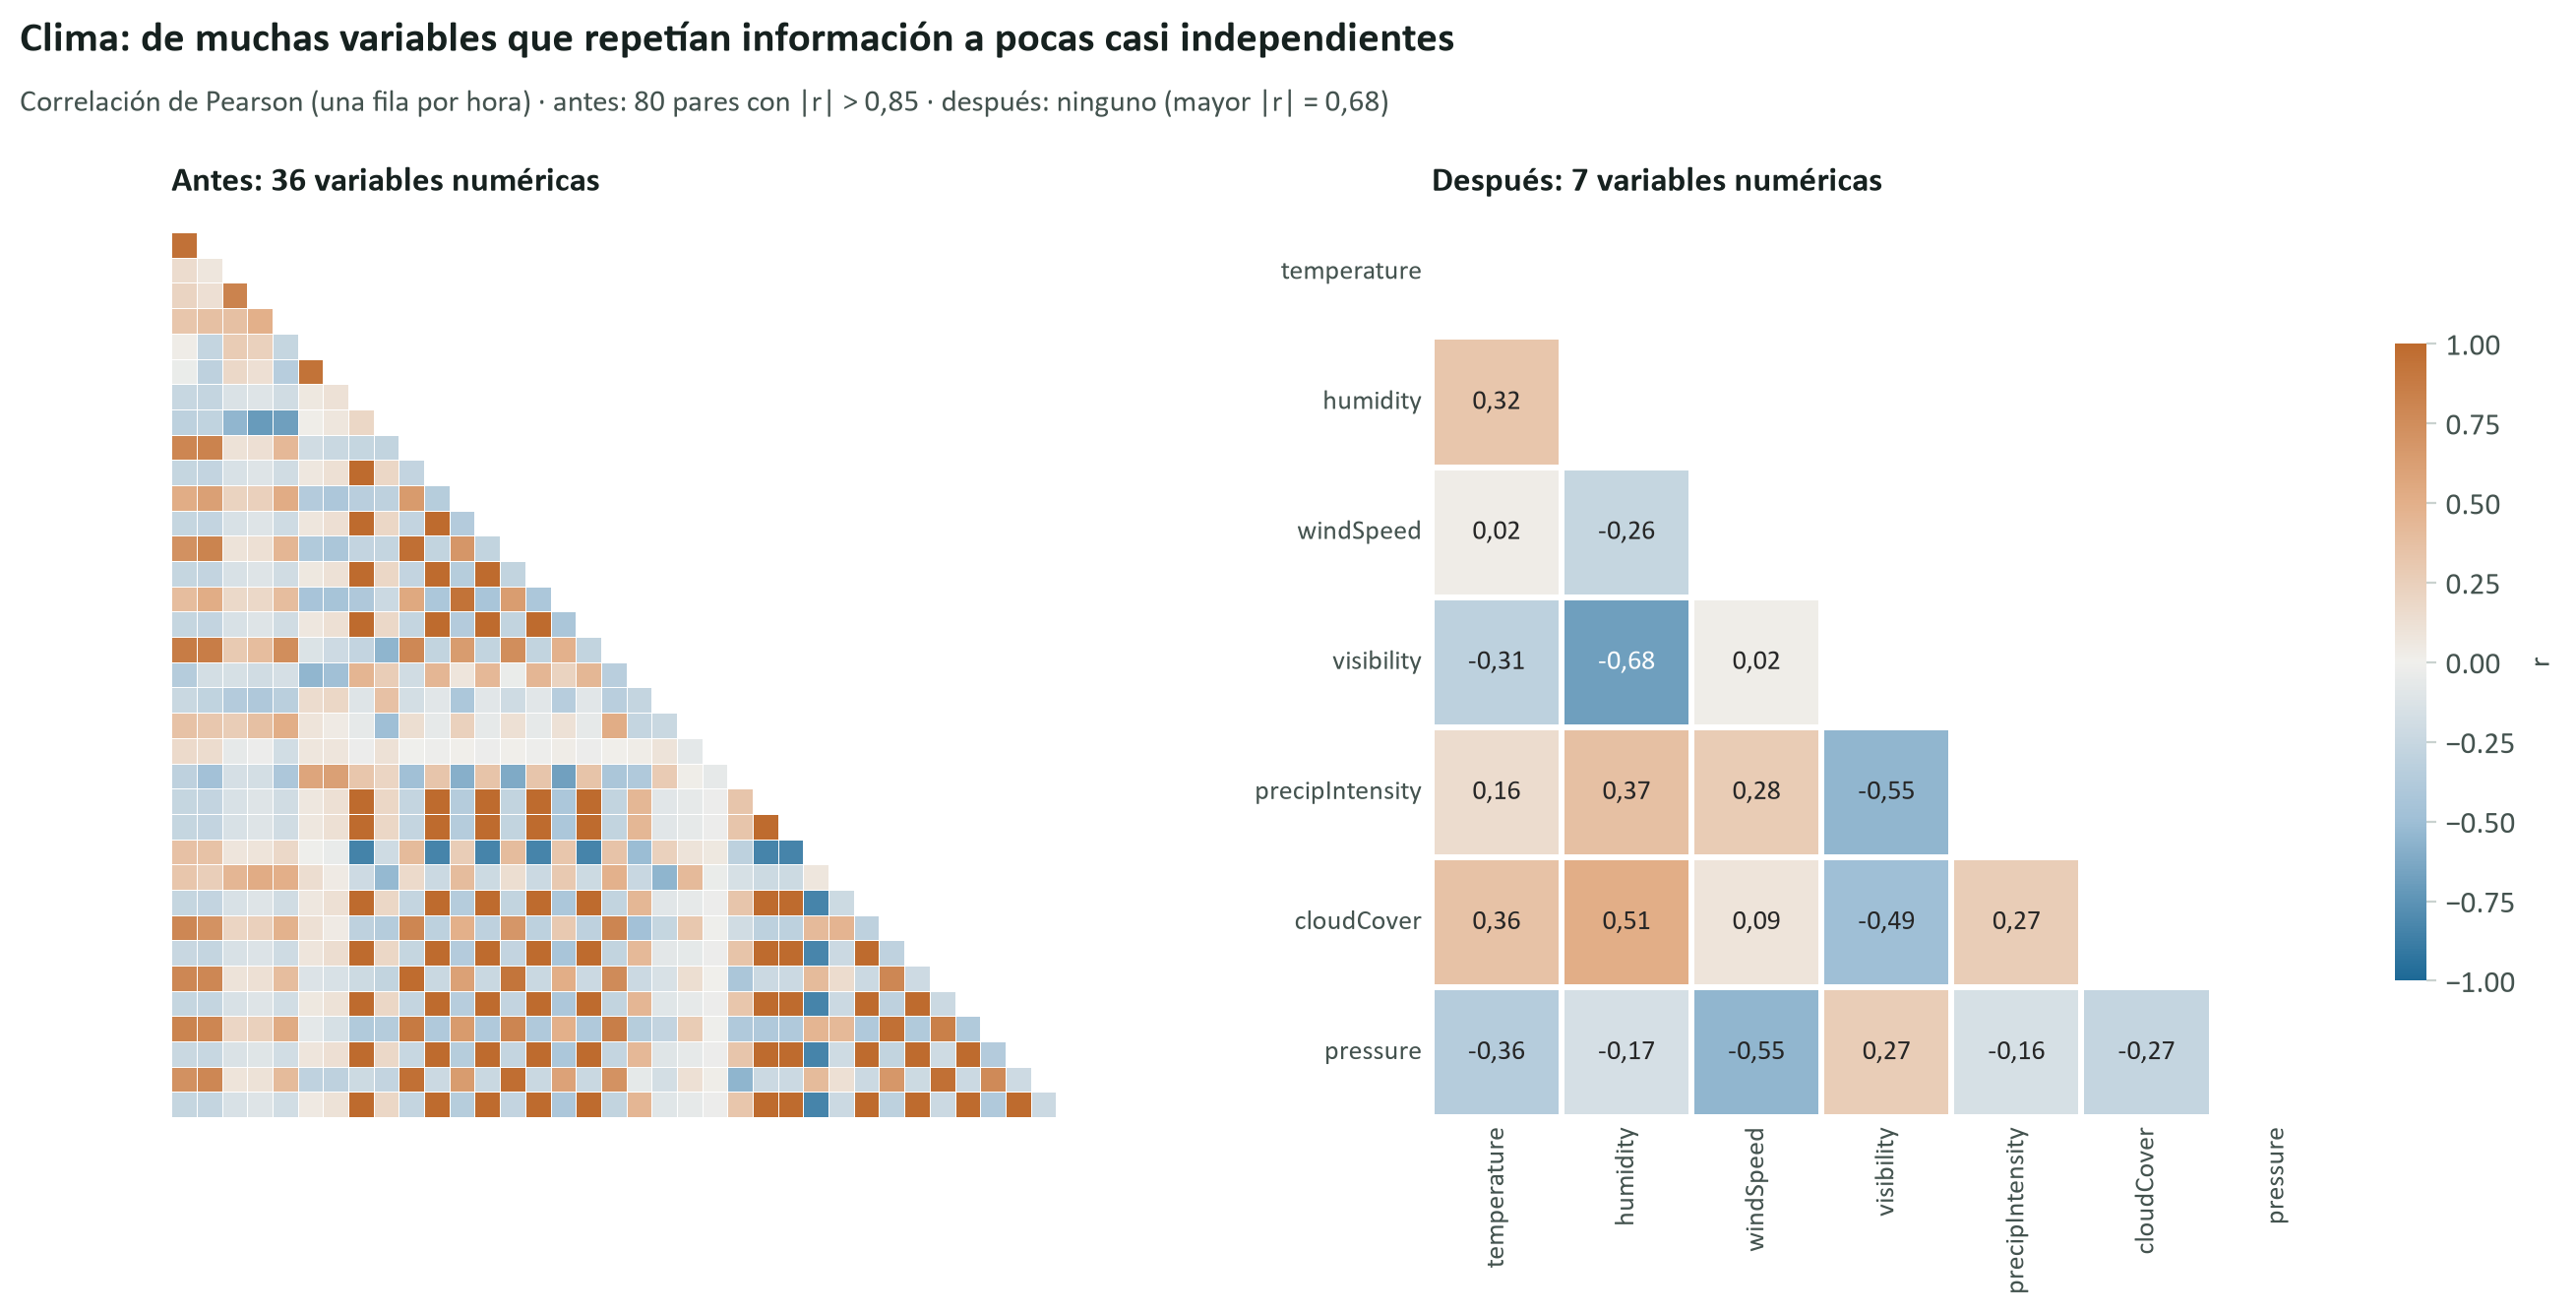

In [9]:
# Correlación del clima en la tabla horaria (una fila por hora)
clima_cols = [c for c in RAW_COLS[RAW_COLS.index("temperature"):] if c != "visibility.1"]
num_antes = [c for c in clima_cols if pd.api.types.is_numeric_dtype(raw[c])]
num_final = ["temperature", "humidity", "windSpeed", "visibility", "precipIntensity", "cloudCover", "pressure"]
tabla_hora = raw.drop_duplicates("hora_utc")
corr = tabla_hora[num_antes].corr()
corr_desp = tabla_hora[num_final].corr()
triang = lambda m: m.where(np.triu(np.ones(m.shape, dtype=bool), k=1)).abs().stack()
pares, max_desp = int((triang(corr) > 0.85).sum()), triang(corr_desp).max()
fig, (a1, a2) = figura(13, 6.6, 1, 2, titulo="Clima: de muchas variables que repetían información a pocas casi independientes",
                       subtitulo=f"Correlación de Pearson (una fila por hora) · antes: {pares} pares con |r| > 0,85 · después: ninguno (mayor |r| = {max_desp:.2f})".replace(".", ","),
                       gridspec_kw={"width_ratios": [1.15, 1]})
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), cmap=CMAP_DIVERGENTE, vmin=-1, vmax=1, center=0, square=True,
            linewidths=.3, linecolor="white", cbar=False, ax=a1, xticklabels=False, yticklabels=False)
a1.set_title(f"Antes: {len(num_antes)} variables numéricas"); a1.grid(False)
etiquetas = corr_desp.apply(lambda col: col.map(lambda v: f"{v:.2f}".replace(".", ",")))
sns.heatmap(corr_desp, mask=np.triu(np.ones_like(corr_desp, dtype=bool)), cmap=CMAP_DIVERGENTE, vmin=-1, vmax=1, center=0, square=True,
            linewidths=1.5, linecolor="white", annot=etiquetas, fmt="", annot_kws={"fontsize": 10}, cbar_kws={"shrink": .7, "label": "r"}, ax=a2)
a2.set_title(f"Después: {len(num_final)} variables numéricas"); a2.grid(False); a2.tick_params(length=0, labelsize=10)
guardar(fig, "04_correlacion_clima_antes_despues")

---
## 4 · Copias, distancias imposibles y precios extremos — Federico Gon · 2:30 – 3:20
- **Copias:** 1.060 cotizaciones con todos los valores iguales (salvo el id) en el mismo segundo → se eliminan.
- **Un error se elimina (gráfico 05):** 348 viajes de Uber informan menos de 0,1 millas entre zonas distintas. La línea recta entre esas zonas ya mide más (desde 0,33 mi) y Lyft nunca informa menos de 0,39 mi.
- **Un extremo real se conserva (gráfico 06):** con el criterio de Tukey (rango intercuartílico × 1,5, por producto) hay 21.665 precios atípicos (3,4%). El 85% se explica por el recargo o por un viaje largo: son precios reales. Se conservan, y en la Entrega 3 se modelará el logaritmo del precio.

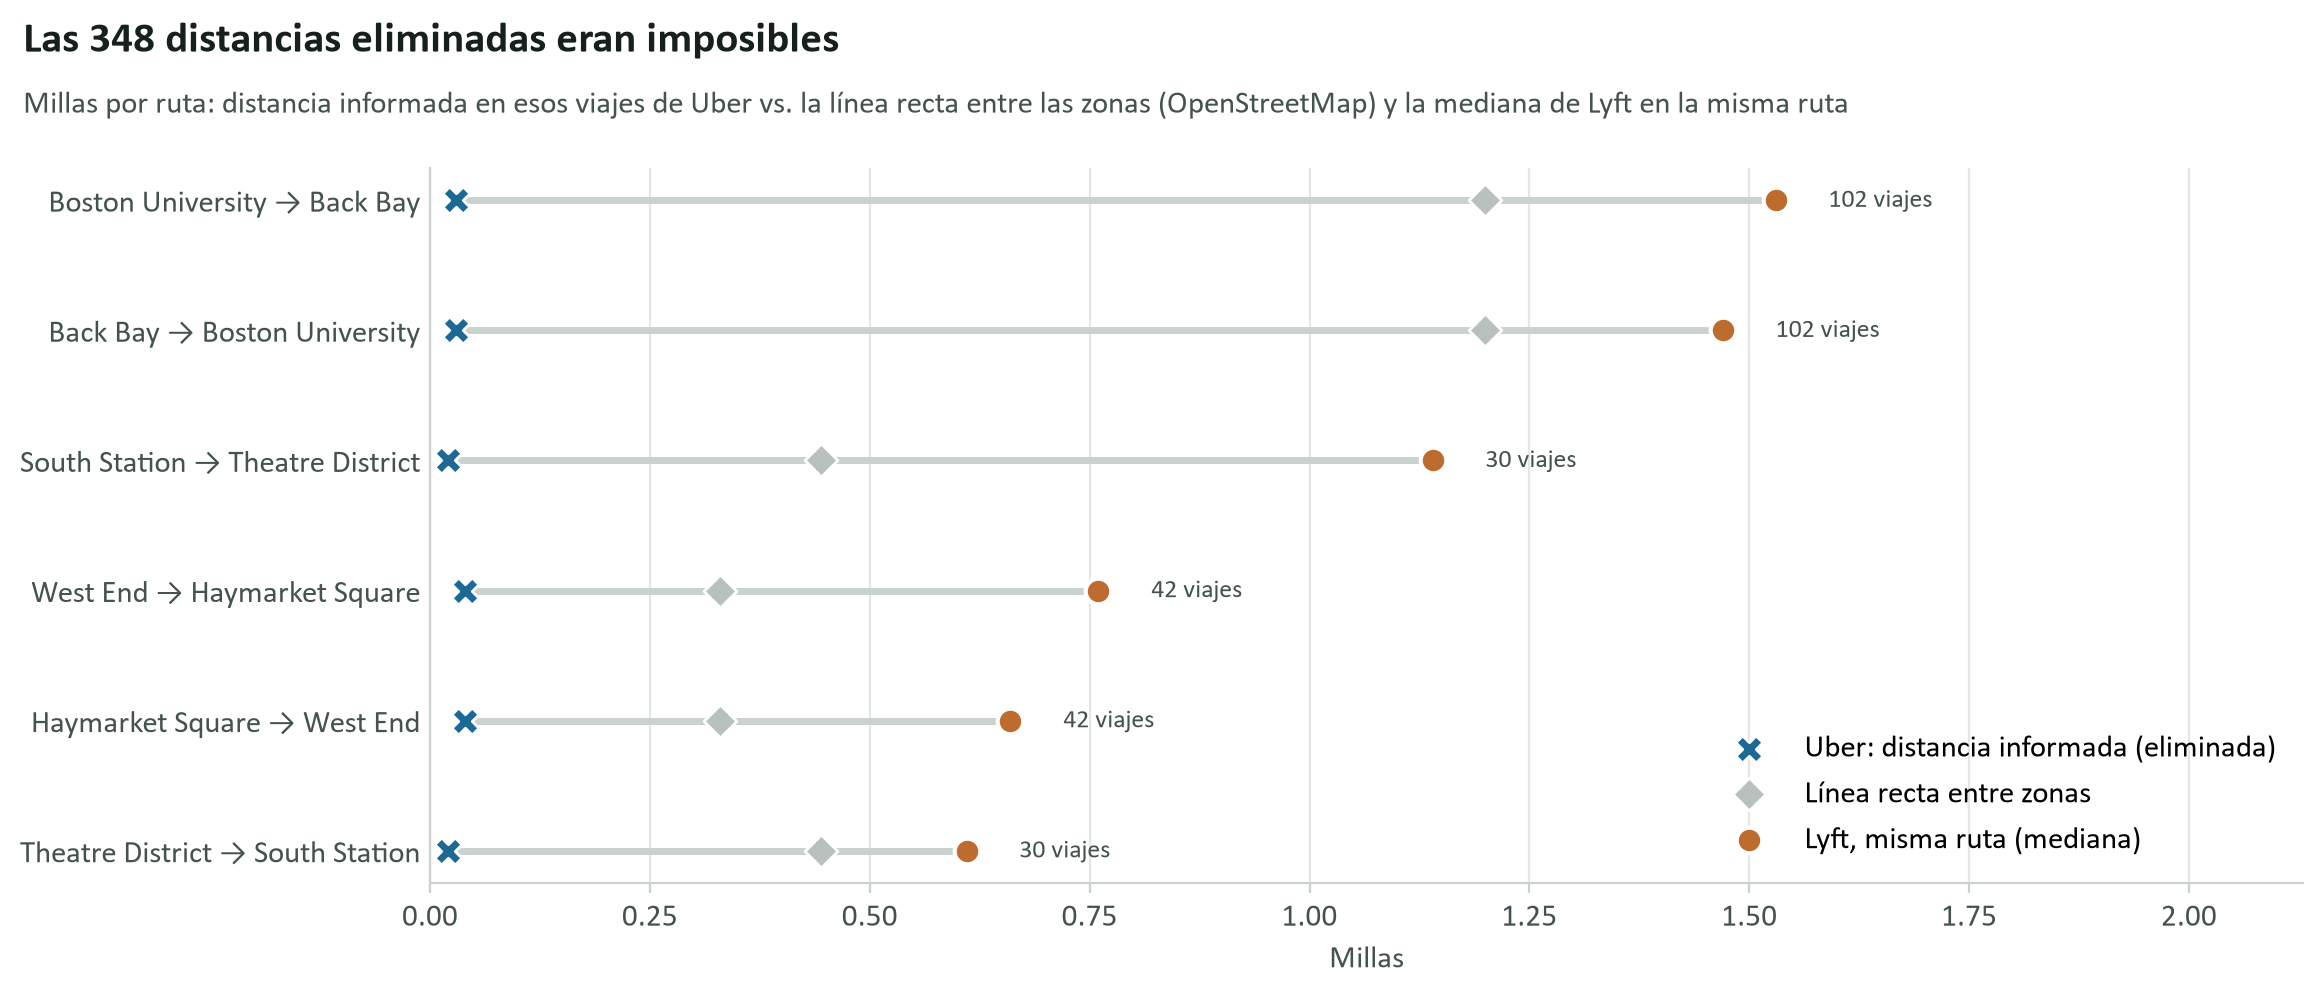

In [10]:
imp = eda[eda["distance"] < 0.1]
rutas = imp.groupby(["source", "destination"])["distance"].agg(["median", "size"]).reset_index()
lyft_med = eda[eda["cab_type"] == "Lyft"].groupby(["source", "destination"])["distance"].median()
rutas["lyft"] = [lyft_med.get((s, d)) for s, d in zip(rutas["source"], rutas["destination"])]
rutas["recta"] = haversine_millas(rutas["source"].map(zc["zone_lat"]), rutas["source"].map(zc["zone_lon"]),
                                  rutas["destination"].map(zc["zone_lat"]), rutas["destination"].map(zc["zone_lon"]))
rutas["ruta"] = rutas["source"] + " → " + rutas["destination"]
rutas = rutas.sort_values("lyft").reset_index(drop=True)
fig, ax = figura(11.5, 4.9, titulo=f"Las {miles(len(imp))} distancias eliminadas eran imposibles",
                 subtitulo="Millas por ruta: distancia informada en esos viajes de Uber vs. la línea recta entre las zonas (OpenStreetMap) y la mediana de Lyft en la misma ruta")
y_rutas = np.arange(len(rutas))
ax.hlines(y_rutas, rutas["median"], rutas["lyft"], color=C["eje"], lw=2.5, zorder=1)
ax.scatter(rutas["median"], y_rutas, s=95, marker="X", color=C["uber"], edgecolor="white", linewidth=1, zorder=3, label="Uber: distancia informada (eliminada)")
ax.scatter(rutas["recta"], y_rutas, s=70, marker="D", color=C["gris"], edgecolor="white", linewidth=1, zorder=3, label="Línea recta entre zonas")
ax.scatter(rutas["lyft"], y_rutas, s=85, color=C["lyft"], edgecolor="white", linewidth=1.5, zorder=3, label="Lyft, misma ruta (mediana)")
for i, r in rutas.iterrows():
    ax.text(r["lyft"] + 0.06, i, f"{r['size']} viajes", va="center", fontsize=9.5, color=C["tinta2"])
ax.set_yticks(y_rutas, rutas["ruta"]); ax.tick_params(axis="y", length=0); ax.grid(axis="y", visible=False)
ax.set_xlabel("Millas"); ax.set_xlim(0, rutas["lyft"].max() + 0.6); ax.legend(loc="lower right")
guardar(fig, "05_distancias_imposibles")

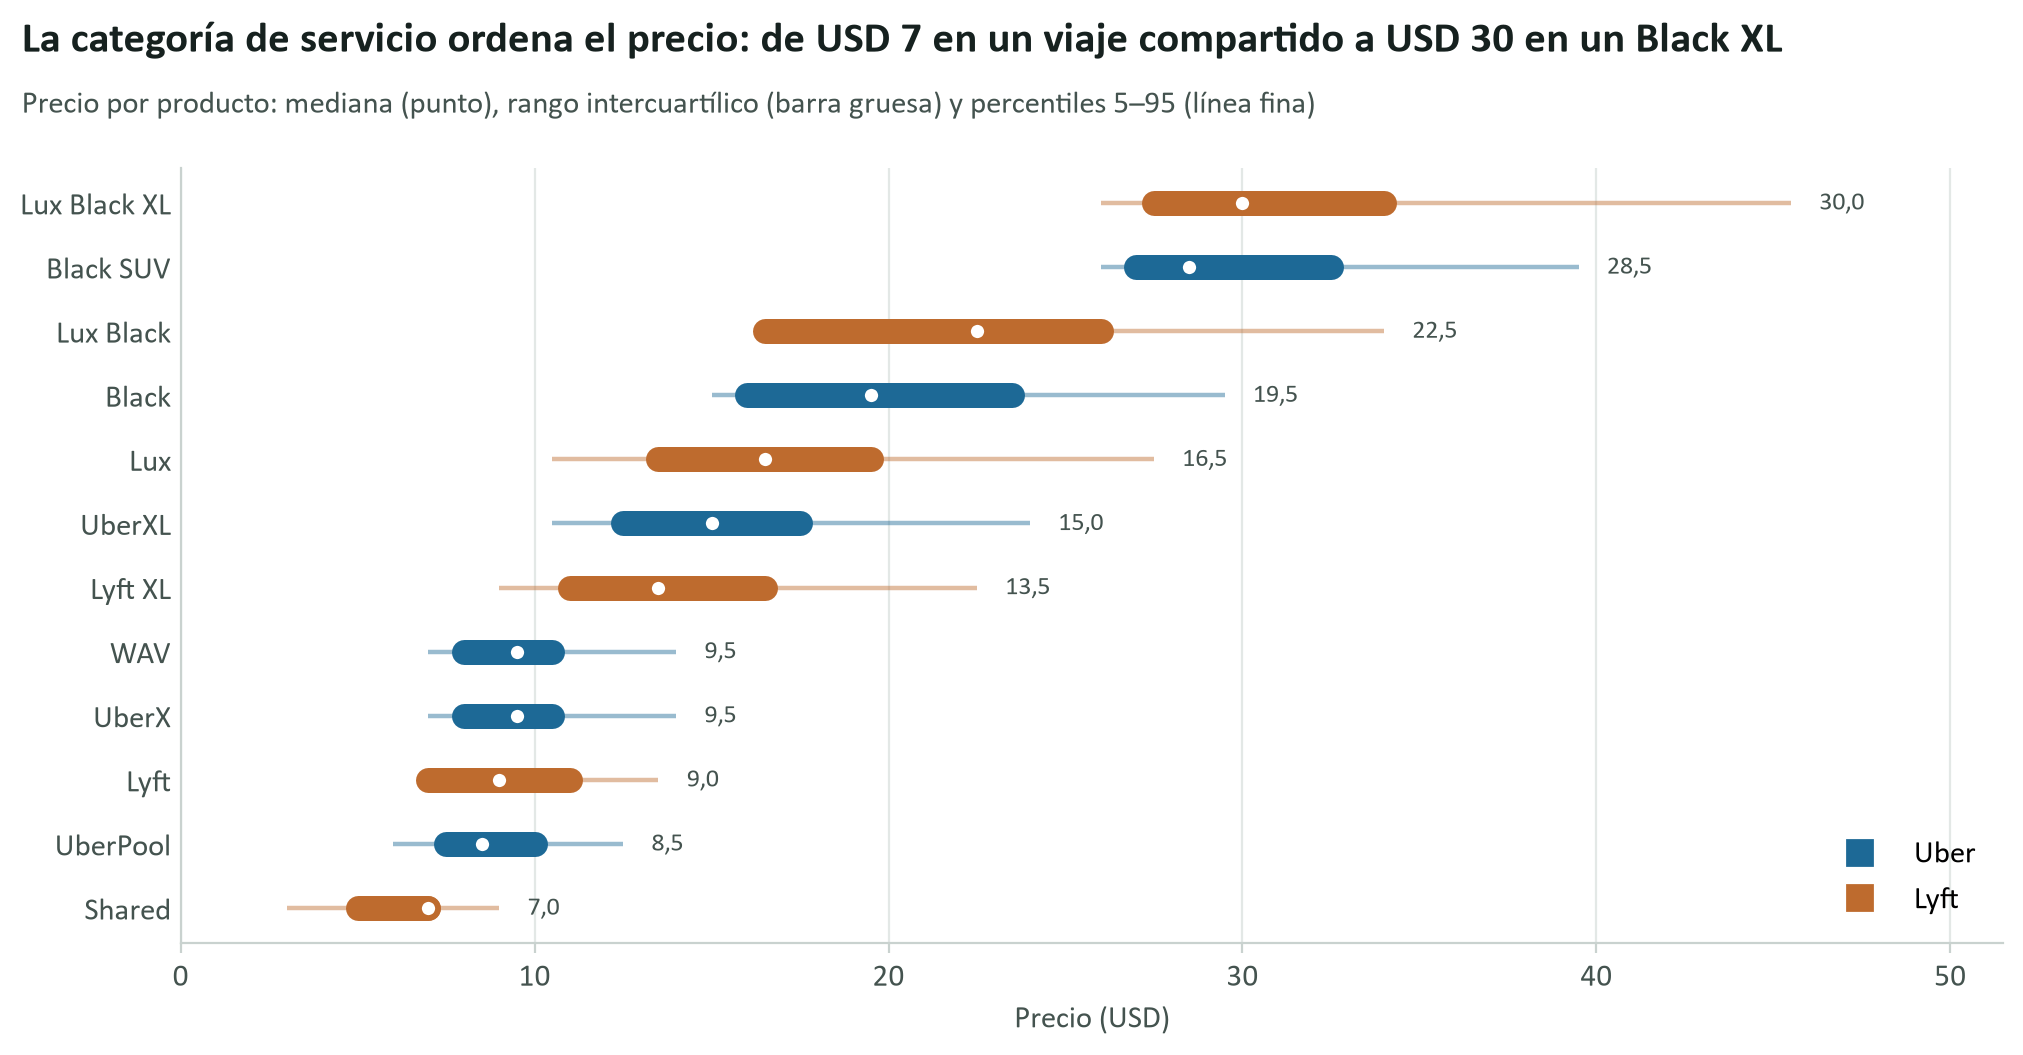

In [11]:
orden = eda.groupby("name")["price"].median().sort_values().index.tolist()
q = eda.groupby("name")["price"].quantile([.05, .25, .5, .75, .95]).unstack()
plat = eda.groupby("name")["cab_type"].first()
fig, ax = figura(10, 5.2, titulo="La categoría de servicio ordena el precio: de USD 7 en un viaje compartido a USD 30 en un Black XL",
                 subtitulo="Precio por producto: mediana (punto), rango intercuartílico (barra gruesa) y percentiles 5–95 (línea fina)")
for i, n in enumerate(orden):
    col = PLATAFORMA[str(plat[n])]
    ax.hlines(i, q.loc[n, .05], q.loc[n, .95], color=col, lw=1.6, alpha=.45)
    ax.hlines(i, q.loc[n, .25], q.loc[n, .75], color=col, lw=9, capstyle="round")
    ax.scatter(q.loc[n, .5], i, s=46, color="white", edgecolor=col, linewidth=2, zorder=4)
    ax.text(q.loc[n, .95] + .8, i, f"{q.loc[n, .5]:.1f}".replace(".", ","), va="center", fontsize=9.5, color=C["tinta2"])
ax.set_yticks(range(len(orden)), orden); ax.tick_params(axis="y", length=0); ax.grid(axis="y", visible=False)
ax.set_xlabel("Precio (USD)"); ax.set_xlim(0, q[.95].max() + 6)
leyenda_plataformas(ax, loc="lower right")
guardar(fig, "06_precio_por_producto")

---
## 5 · Las dos variables a predecir — Sofía Medina · 3:20 – 4:10
- **`price` (gráfico 07):** el producto elegido explica el 77% de la variación del precio y la distancia el 12%; juntos, el 92%. La hora y el clima, casi nada.
- **`has_surge` = 1 si `surge_multiplier` > 1 (gráfico 08):**
  - **Solo Lyft:** Uber figura ×1 en el 100% de sus cotizaciones (gráfico 14).
  - **Sin Shared:** Lyft Shared nunca tiene recargo, 0 de 51.233 (gráfico 15).
  - **Sí/no y no el multiplicador:** los recargos altos casi no existen (×2,5: 154 casos; ×3: 12). Como sí/no quedan **20.975 viajes con recargo (8,19%)**, suficientes para entrenar un modelo.

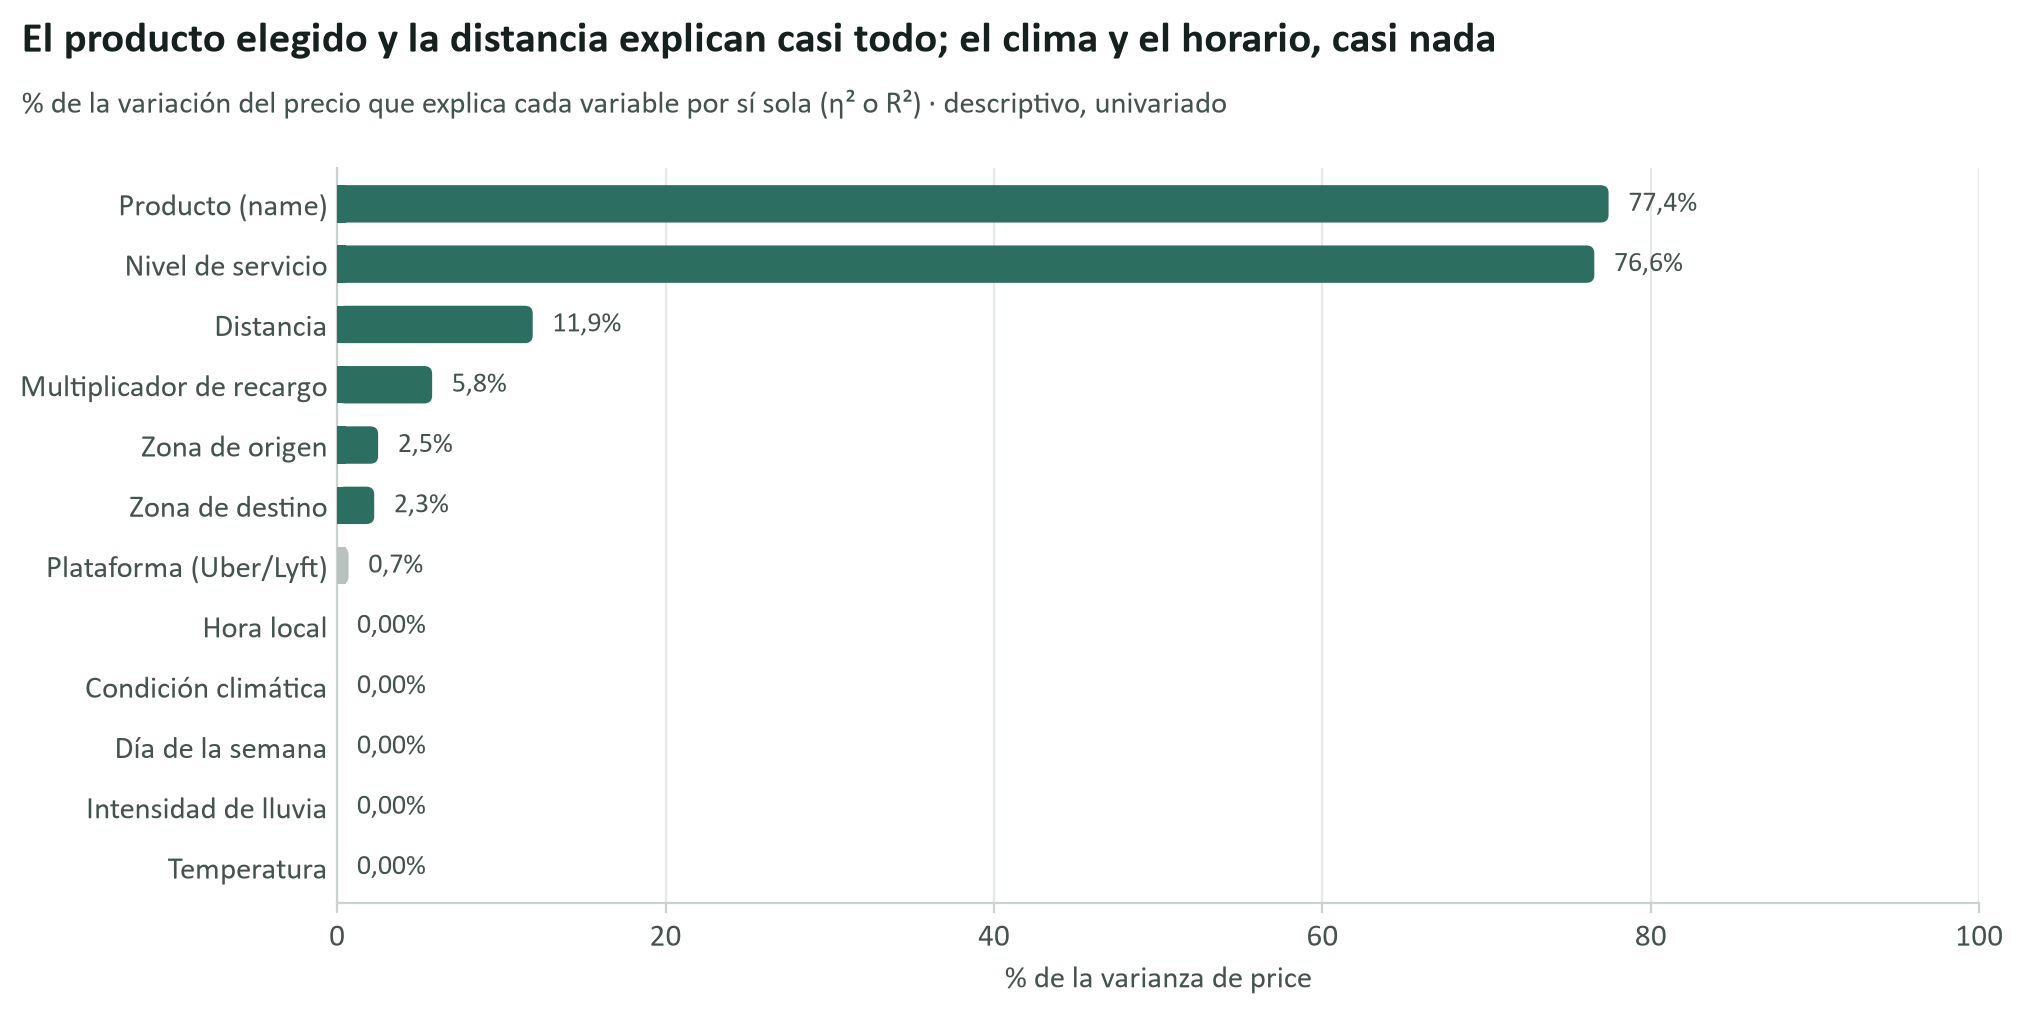

In [12]:
def eta2(y, g):
    medias = y.groupby(g).transform("mean")
    return float(((medias - y.mean()) ** 2).sum() / ((y - y.mean()) ** 2).sum())
def r2_lineal(y, x):
    return float(np.corrcoef(x, y)[0, 1] ** 2)
y = eda["price"]
peso = pd.Series({
    "Producto (name)": eta2(y, eda["name"]), "Nivel de servicio": eta2(y, eda["service_tier"]),
    "Distancia": r2_lineal(y, eda["distance"]), "Multiplicador de recargo": r2_lineal(y, eda["surge_multiplier"]),
    "Plataforma (Uber/Lyft)": eta2(y, eda["cab_type"]), "Zona de origen": eta2(y, eda["source"]),
    "Zona de destino": eta2(y, eda["destination"]), "Hora local": eta2(y, eda["hour_local"]),
    "Día de la semana": eta2(y, eda["day_of_week"]), "Condición climática": eta2(y, eda["short_summary"]),
    "Temperatura": r2_lineal(y, eda["temperature"]), "Intensidad de lluvia": r2_lineal(y, eda["precipIntensity"]),
}).sort_values(ascending=False)
fig, ax = figura(10, 5.0, titulo="El producto elegido y la distancia explican casi todo; el clima y el horario, casi nada",
                 subtitulo="% de la variación del precio que explica cada variable por sí sola (η² o R²) · descriptivo, univariado")
barras_h(ax, peso.index.tolist(), (100 * peso).values, [C["serie"] if v >= 0.01 else C["gris"] for v in peso.values],
         fmt=lambda v: (f"{v:.1f}%" if v >= 0.1 else f"{v:.2f}%").replace(".", ","), xmax=100)
ax.set_xlabel("% de la varianza de price")
guardar(fig, "07_peso_de_cada_factor")

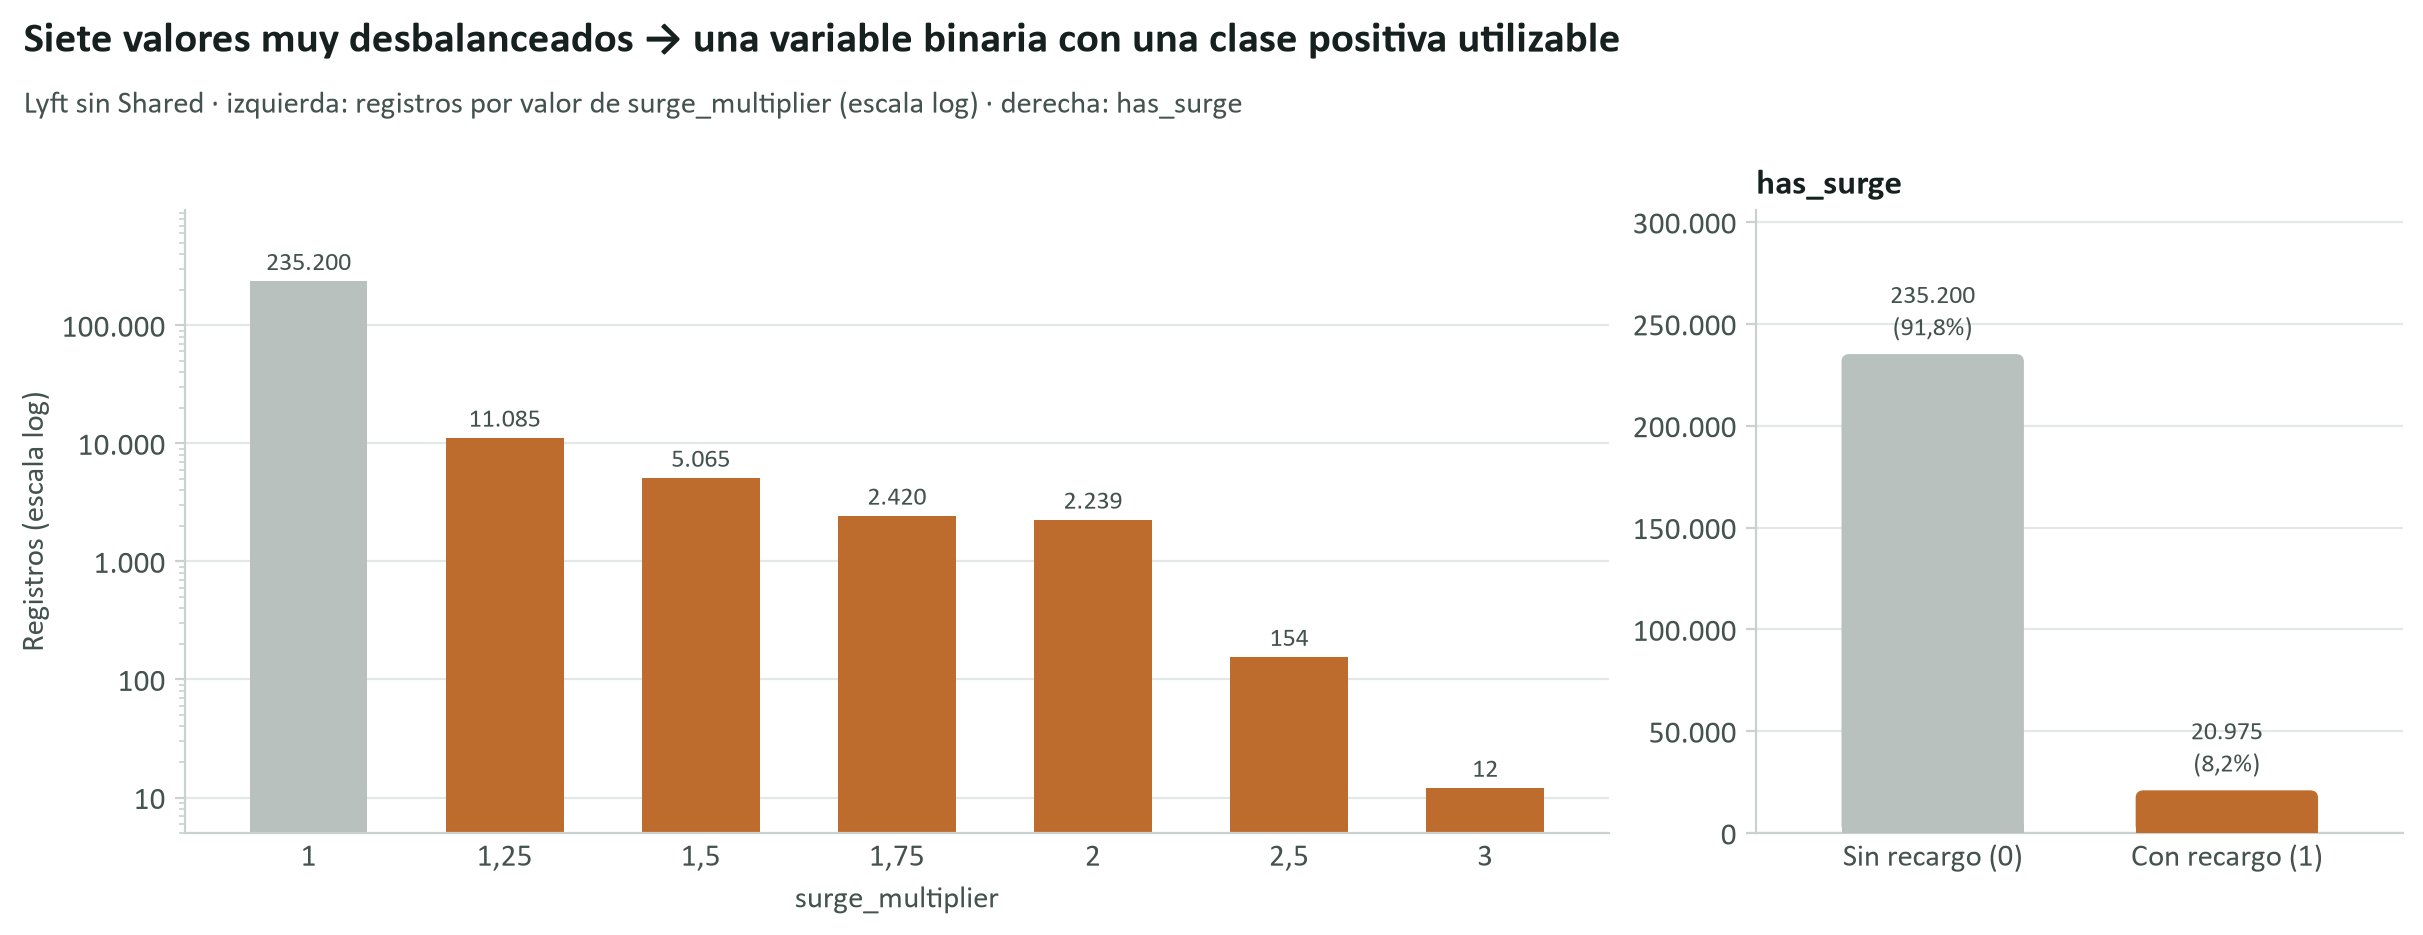

In [13]:
vc = lyft_s["surge_multiplier"].value_counts().sort_index()
binaria = lyft_s["has_surge"].value_counts().sort_index()
fig, (a1, a2) = figura(12, 4.6, 1, 2, titulo="Siete valores muy desbalanceados → una variable binaria con una clase positiva utilizable",
                       subtitulo="Lyft sin Shared · izquierda: registros por valor de surge_multiplier (escala log) · derecha: has_surge",
                       gridspec_kw={"width_ratios": [2.2, 1]})
a1.bar(range(len(vc)), vc.values, color=[C["gris"] if v == 1 else C["lyft"] for v in vc.index], width=.6)
a1.set_yscale("log"); a1.set_xticks(range(len(vc)), [f"{v:g}".replace(".", ",") for v in vc.index]); a1.set_xlabel("surge_multiplier"); a1.set_ylabel("Registros (escala log)")
a1.grid(axis="x", visible=False); a1.tick_params(axis="x", length=0)
for i, v in enumerate(vc.values):
    a1.text(i, v * 1.25, miles(v), ha="center", fontsize=9.5, color=C["tinta2"])
a1.set_ylim(5, vc.max() * 4); a1.yaxis.set_major_formatter(lambda v, p: miles(v))
barras_v(a2, ["Sin recargo (0)", "Con recargo (1)"], binaria.values, [C["gris"], C["lyft"]],
         fmt=lambda v: f"{miles(v)}\n({pct(100 * v / binaria.sum())})", ymax=binaria.max() * 1.3)
a2.yaxis.set_major_formatter(lambda v, p: miles(v)); a2.set_title("has_surge")
guardar(fig, "08_recargo_distribucion")

---
## 6 · Qué explica el recargo, pautas y cierre — Facundo Dagnino Dailly · 4:10 – 5:00
- **Gráfico 09:** el recargo depende sobre todo de la zona de origen: Back Bay 13,4% vs. North End 1,8%. La hora lo mueve poco (entre 7,0% y 9,6%) y la lluvia no lo cambia.
- **Gráfico 10:** con recargo, el mismo viaje cuesta en promedio un 46% más (por producto, el precio mediano sube entre 36% y 67%). Por eso `price` no puede usarse para predecir `has_surge`: ya trae la respuesta (fuga de datos).
- **Pautas para la Entrega 3:**

| Pauta | Por qué |
|---|---|
| `price`: usar todas las filas y modelar log(price) | El precio tiene cola a la derecha |
| `has_surge`: solo Lyft sin Shared, **sin** `price` ni `surge_multiplier` | Ya contienen la respuesta (fuga de datos) |
| Medir `has_surge` con PR-AUC, recall y F1, no con accuracy | Decir siempre "no" ya acierta el 91,8% |
| Validar con días que el modelo no vio (agrupar por fecha) | Las cotizaciones de la misma ruta y minuto comparten el recargo (96%) |

**Gracias. Quedamos atentos a las preguntas.**

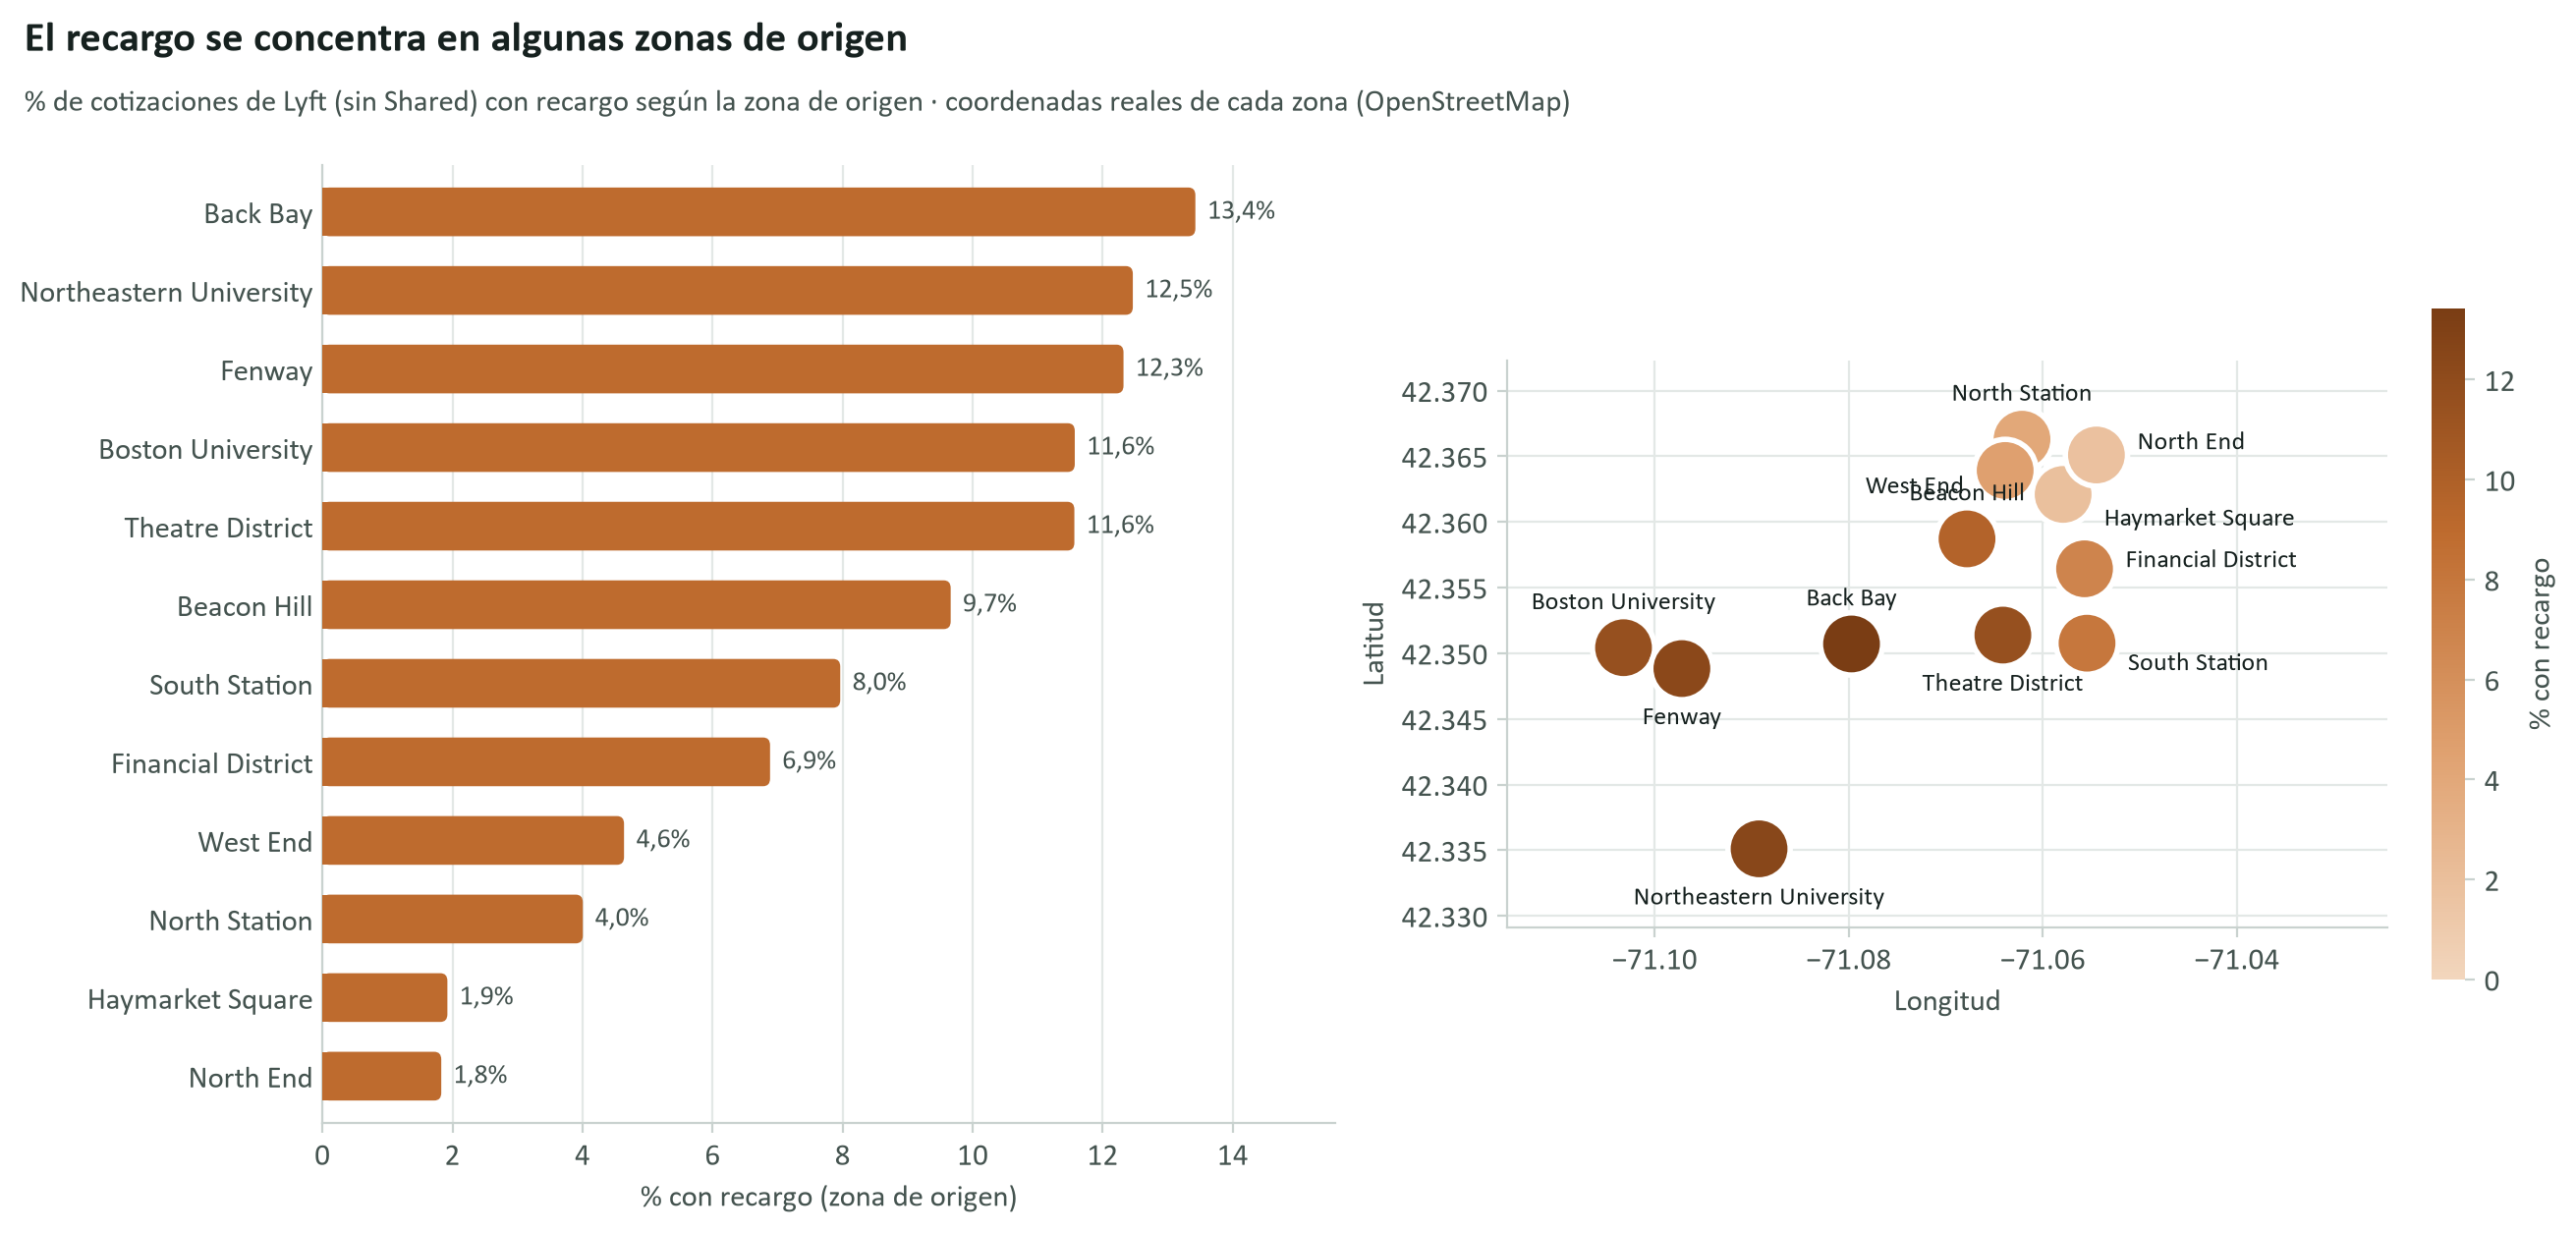

In [14]:
por_zona = lyft_s.groupby("source")["has_surge"].mean().mul(100).rename("pct_origen")
zz = zonas.set_index("zone").join(por_zona)
orden_z = zz["pct_origen"].sort_values(ascending=False)
fig, (a1, a2) = figura(13, 6.2, 1, 2, titulo="El recargo se concentra en algunas zonas de origen",
                       subtitulo="% de cotizaciones de Lyft (sin Shared) con recargo según la zona de origen · coordenadas reales de cada zona (OpenStreetMap)",
                       gridspec_kw={"width_ratios": [1.15, 1]})
barras_h(a1, orden_z.index.tolist(), orden_z.values, C["lyft"], fmt=lambda v: pct(v, 1))
a1.set_xlabel("% con recargo (zona de origen)")
sc = a2.scatter(zz.zone_lon, zz.zone_lat, c=zz.pct_origen, cmap=CMAP_PUNTOS, s=520, edgecolor="white", linewidth=2, vmin=0, vmax=zz.pct_origen.max(), zorder=3)
for z, r in zz.iterrows():
    dx, dy, ha = ETIQ_ZONAS[z]
    a2.annotate(z, (r.zone_lon, r.zone_lat), textcoords="offset points", xytext=(dx * 1.5, dy * 1.5), ha=ha, va="center", fontsize=9.5, color=C["tinta"])
a2.set_aspect(1 / np.cos(np.deg2rad(42.355))); a2.set_xlabel("Longitud"); a2.set_ylabel("Latitud")
a2.set_xlim(zz.zone_lon.min() - 0.012, zz.zone_lon.max() + 0.03); a2.set_ylim(zz.zone_lat.min() - 0.006, zz.zone_lat.max() + 0.006)
cb = fig.colorbar(sc, ax=a2, shrink=.7, label="% con recargo"); cb.outline.set_visible(False)
guardar(fig, "09_recargo_por_zona")

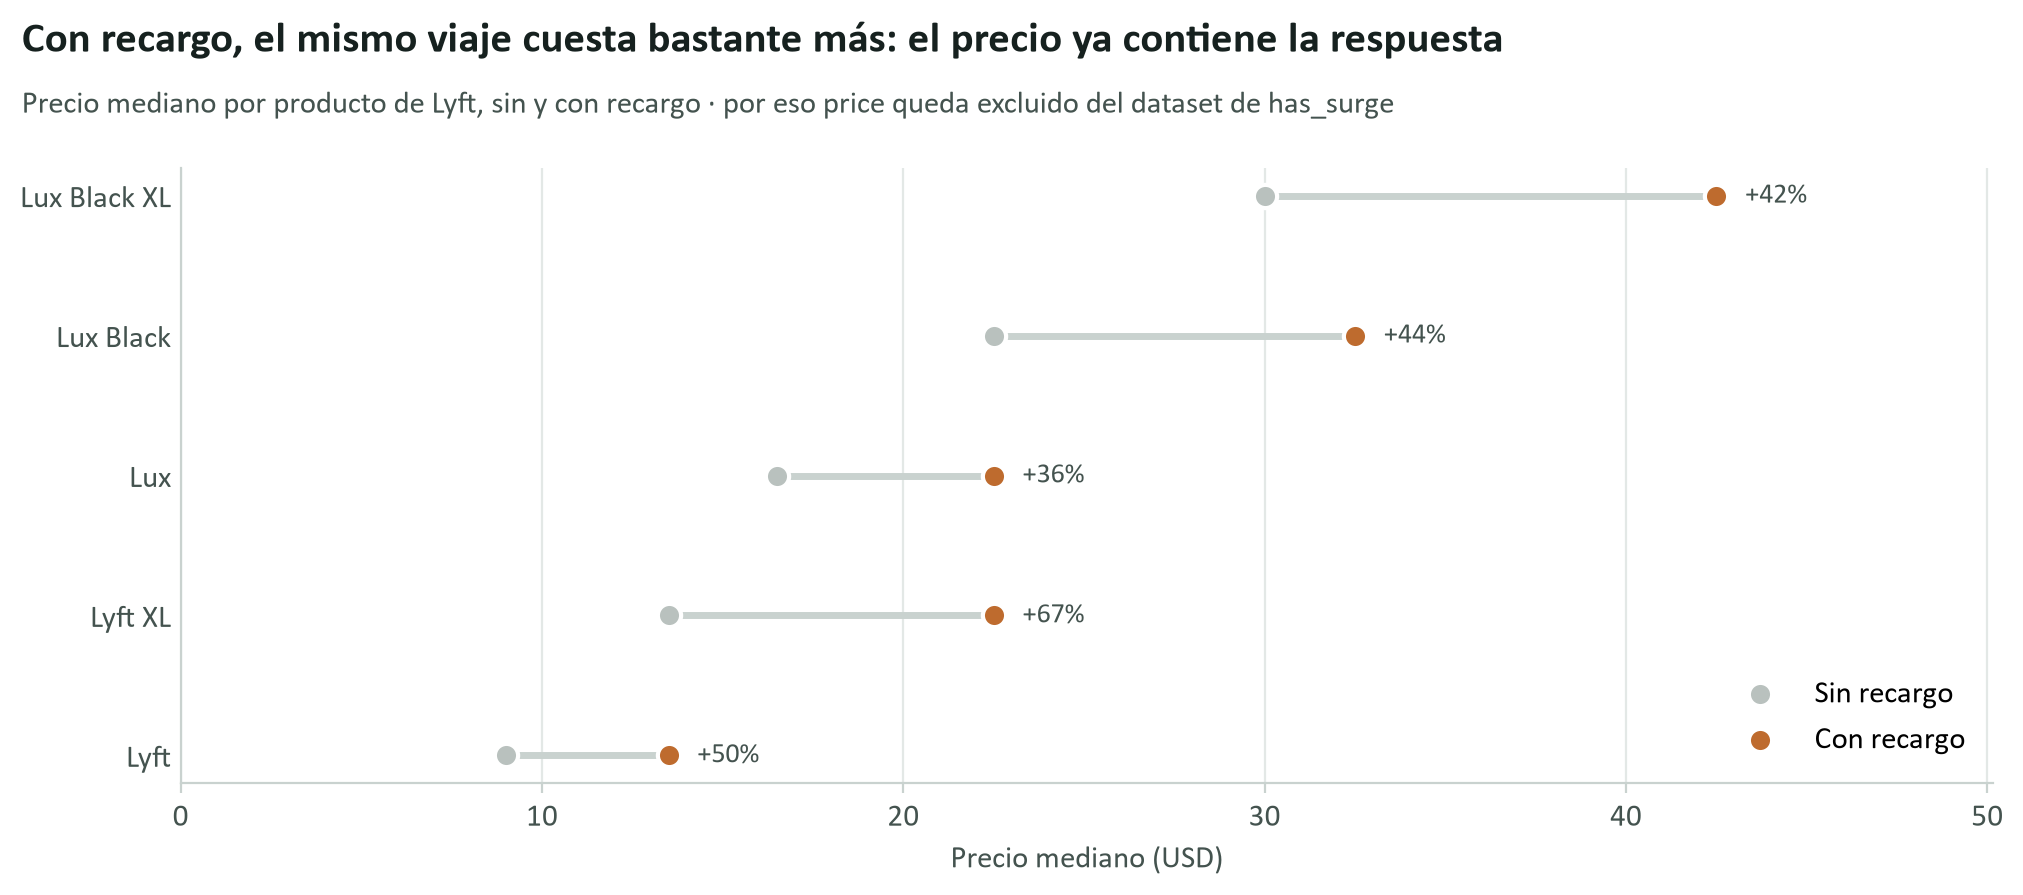

In [15]:
prod_ratio = lyft_s.groupby(["name", "has_surge"])["price"].median().unstack()
prod_ratio["aumento_%"] = (100 * (prod_ratio[1] / prod_ratio[0] - 1)).round(1)
orden_p = prod_ratio.sort_values(0).index.tolist()
yy = np.arange(len(orden_p))
fig, ax = figura(10, 4.4, titulo="Con recargo, el mismo viaje cuesta bastante más: el precio ya contiene la respuesta",
                 subtitulo="Precio mediano por producto de Lyft, sin y con recargo · por eso price queda excluido del dataset de has_surge")
ax.hlines(yy, prod_ratio.loc[orden_p, 0], prod_ratio.loc[orden_p, 1], color=C["eje"], lw=2.5, zorder=1)
ax.scatter(prod_ratio.loc[orden_p, 0], yy, s=70, color=C["gris"], edgecolor="white", linewidth=1.5, zorder=3, label="Sin recargo")
ax.scatter(prod_ratio.loc[orden_p, 1], yy, s=70, color=C["lyft"], edgecolor="white", linewidth=1.5, zorder=3, label="Con recargo")
for i, n in enumerate(orden_p):
    ax.text(prod_ratio.loc[n, 1] + .8, i, f"+{prod_ratio.loc[n, 'aumento_%']:.0f}%", va="center", fontsize=10, color=C["tinta2"])
ax.set_yticks(yy, orden_p); ax.tick_params(axis="y", length=0); ax.grid(axis="y", visible=False)
ax.set_xlabel("Precio mediano (USD)"); ax.set_xlim(0, prod_ratio[1].max() * 1.18); ax.legend(loc="lower right")
guardar(fig, "10_precio_con_y_sin_recargo")

---
## Anexo · Gráficos de respaldo (para responder preguntas)

**11 · ¿Faltan datos en el tiempo?** Sí: hay datos en 18 de las 24 fechas (6 sin datos y 4 parciales). Por hora la cobertura es pareja. Las conclusiones por día de la semana se toman con cuidado.

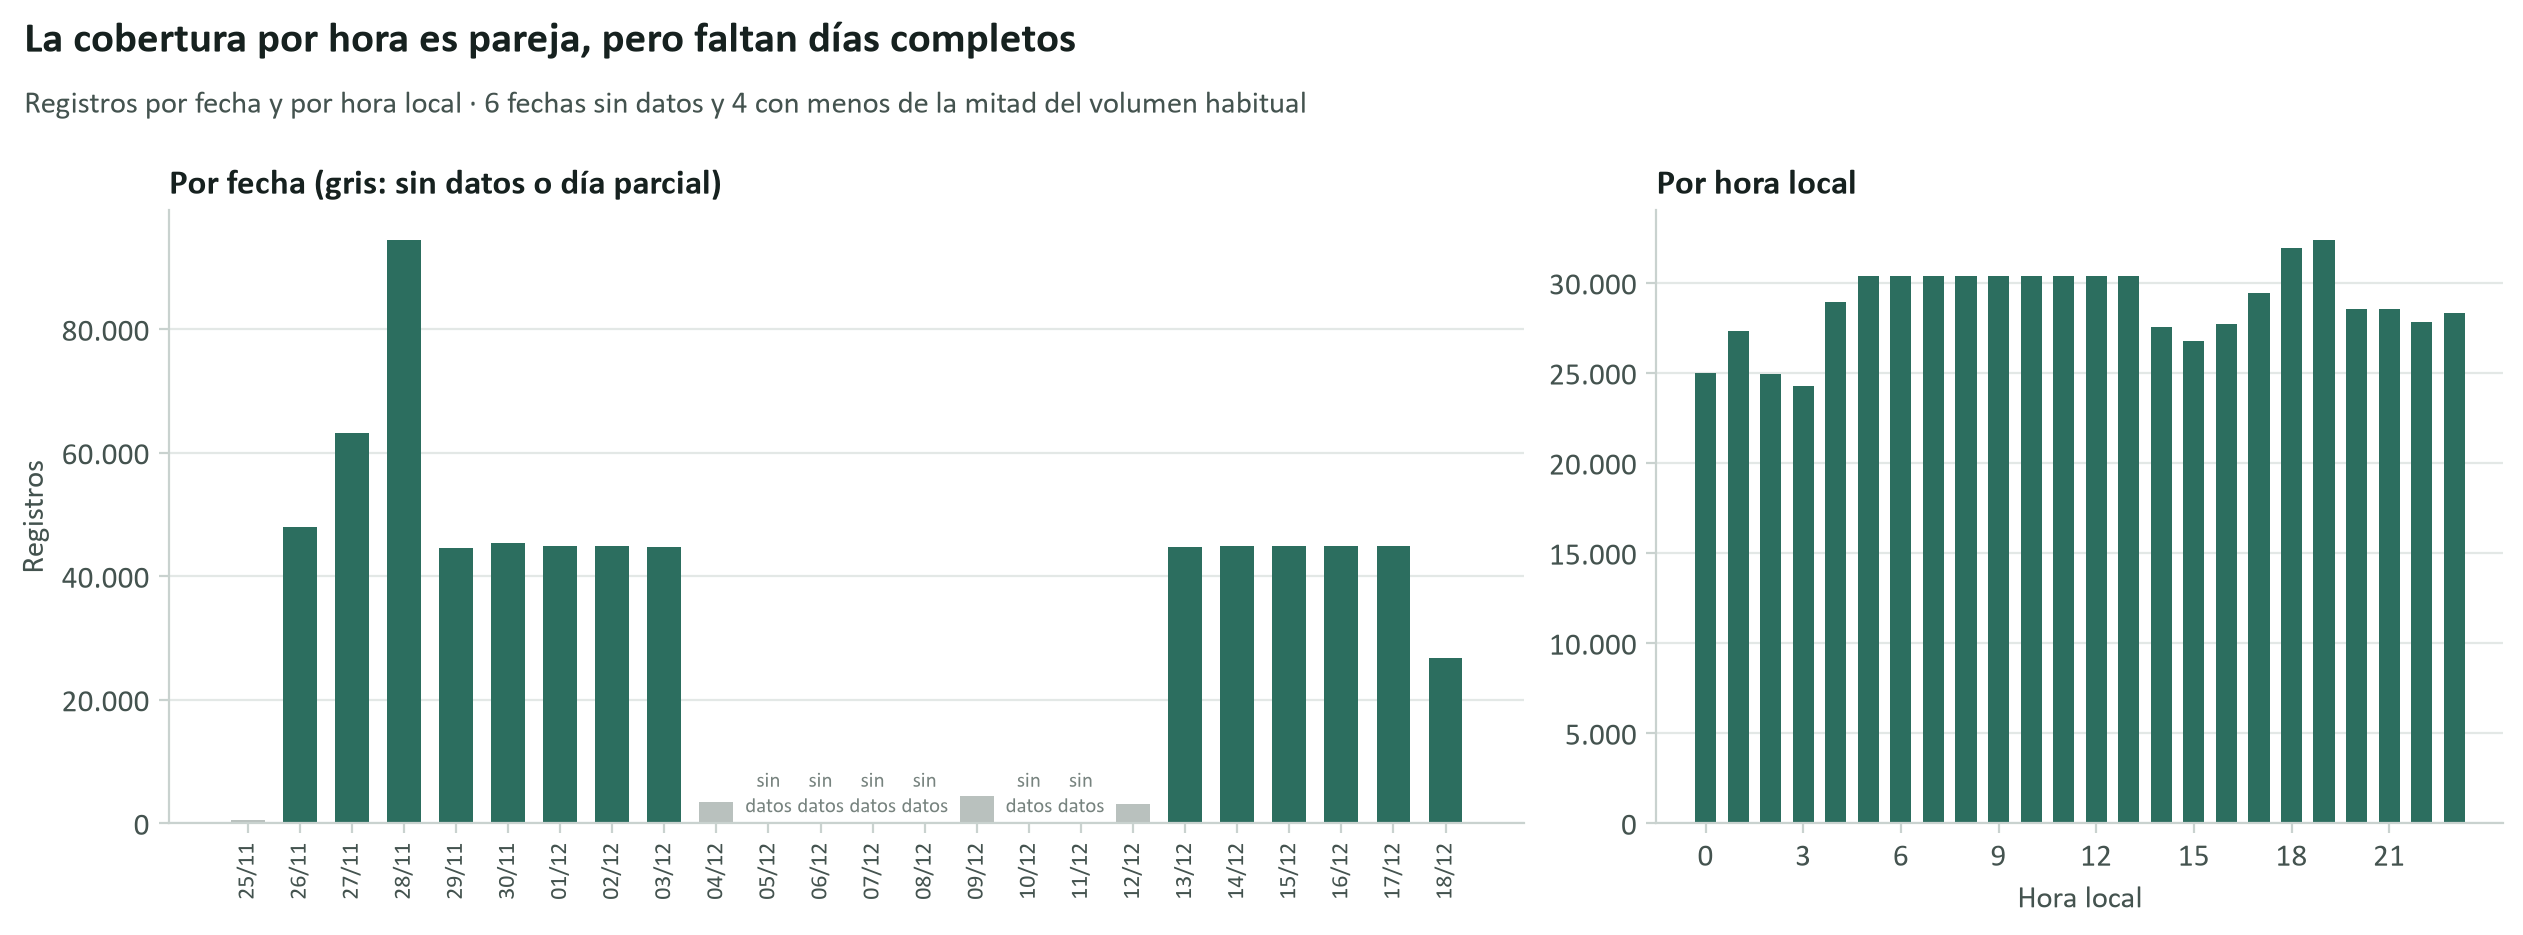

In [16]:
por_fecha = raw.groupby("date_local").size()
rango = pd.date_range(por_fecha.index.min(), por_fecha.index.max(), freq="D")
por_fecha = por_fecha.reindex(rango, fill_value=0)
mediana_dia = por_fecha[por_fecha > 0].median()
n_sin = int((por_fecha == 0).sum()); n_parc = int(((por_fecha > 0) & (por_fecha < 0.5 * mediana_dia)).sum())
por_hora_n = raw.groupby("hour_local").size()
fig, (a1, a2) = figura(12.5, 4.6, 1, 2, titulo="La cobertura por hora es pareja, pero faltan días completos",
                       subtitulo=f"Registros por fecha y por hora local · {n_sin} fechas sin datos y {n_parc} con menos de la mitad del volumen habitual",
                       gridspec_kw={"width_ratios": [1.6, 1]})
cols_f = [C["gris"] if (v < 0.5 * mediana_dia) else C["serie"] for v in por_fecha.values]
a1.bar(range(len(por_fecha)), por_fecha.values, color=cols_f, width=.65)
for i, v in enumerate(por_fecha.values):
    if v == 0:
        a1.text(i, mediana_dia * 0.04, "sin\ndatos", ha="center", fontsize=7.5, color=C["muted"])
a1.set_xticks(range(len(por_fecha)), [d.strftime("%d/%m") for d in por_fecha.index], rotation=90, fontsize=8.5)
a1.yaxis.set_major_formatter(lambda v, p: miles(v)); a1.set_ylabel("Registros"); a1.grid(axis="x", visible=False)
a1.set_title("Por fecha (gris: sin datos o día parcial)")
a2.bar(por_hora_n.index, por_hora_n.values, color=C["serie"], width=.65)
a2.set_xticks(range(0, 24, 3)); a2.set_xlabel("Hora local"); a2.yaxis.set_major_formatter(lambda v, p: miles(v))
a2.grid(axis="x", visible=False); a2.set_title("Por hora local")
guardar(fig, "11_cobertura_temporal")

**12 · ¿El clima es el de la zona del viaje?** No. Hay un solo registro de clima por hora y `latitude`/`longitude` son las de ese registro: coinciden con el origen del viaje en el 8,4% de los casos, lo mismo que al azar (8,3%). Se usa como clima de la ciudad en cada hora y las coordenadas se eliminan.

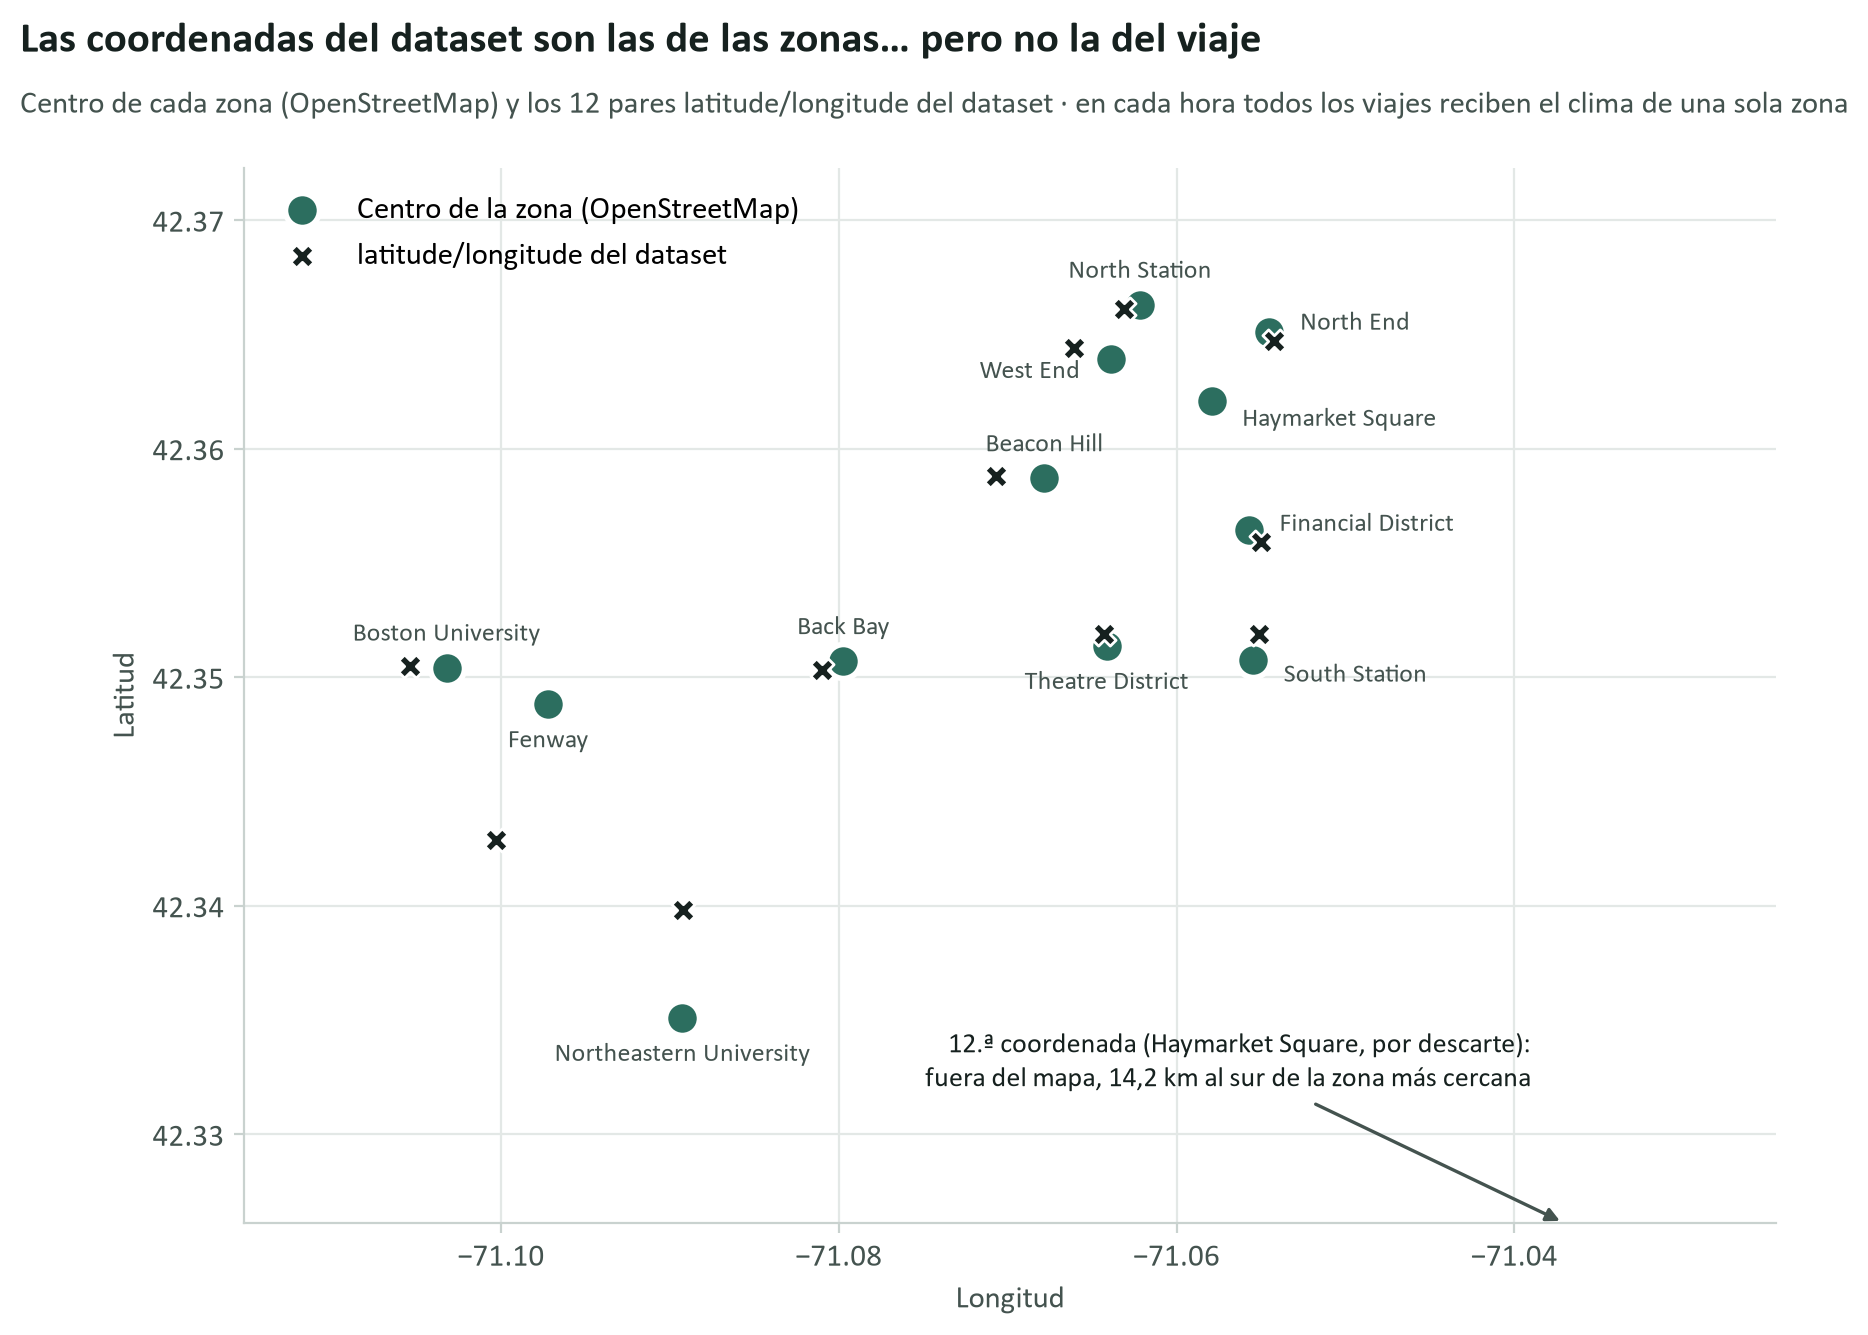

In [17]:
coords_clima = raw.groupby(["latitude", "longitude"]).size().rename("registros").reset_index()
dist_min = []
for _, r in coords_clima.iterrows():
    d = haversine_millas(r.latitude, r.longitude, zonas.zone_lat.values, zonas.zone_lon.values) * 1.609344
    dist_min.append((d.min(), zonas.zone.values[d.argmin()]))
coords_clima["km"] = [x[0] for x in dist_min]; coords_clima["zona"] = [x[1] for x in dist_min]
cerca = coords_clima["km"] <= 1
faltante = sorted(set(zonas.zone) - set(coords_clima.loc[cerca, "zona"]))
fig, ax = figura(10, 6.6, titulo="Las coordenadas del dataset son las de las zonas… pero no la del viaje",
                 subtitulo="Centro de cada zona (OpenStreetMap) y los 12 pares latitude/longitude del dataset · en cada hora todos los viajes reciben el clima de una sola zona")
ax.scatter(zonas.zone_lon, zonas.zone_lat, s=150, color=C["serie"], edgecolor="white", linewidth=2, zorder=3, label="Centro de la zona (OpenStreetMap)")
dentro = coords_clima[cerca]
ax.scatter(dentro.longitude, dentro.latitude, s=70, marker="X", color=C["tinta"], edgecolor="white", linewidth=1, zorder=4, label="latitude/longitude del dataset")
for _, r in zonas.iterrows():
    dx, dy, ha = ETIQ_ZONAS[r.zone]
    ax.annotate(r.zone, (r.zone_lon, r.zone_lat), textcoords="offset points", xytext=(dx * 1.1, dy * 1.1), ha=ha, va="center", fontsize=9.5, color=C["tinta2"])
ax.set_aspect(1 / np.cos(np.deg2rad(42.355)))
ax.set_xlim(zonas.zone_lon.min() - 0.012, zonas.zone_lon.max() + 0.03); ax.set_ylim(zonas.zone_lat.min() - 0.009, zonas.zone_lat.max() + 0.006)
lejana = coords_clima[~cerca].iloc[0]
xl = float(np.clip(lejana.longitude, *ax.get_xlim()))
ax.annotate(f"12.ª coordenada ({faltante[0]}, por descarte):\nfuera del mapa, {lejana['km']:.1f} km al sur de la zona más cercana".replace(".", ",").replace("12,ª", "12.ª"),
            xy=(xl - 0.004, ax.get_ylim()[0]), xytext=(xl - 0.006, ax.get_ylim()[0] + 0.006), ha="right", fontsize=10, color=C["tinta"],
            arrowprops=dict(arrowstyle="-|>", color=C["tinta2"], lw=1.2))
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud"); ax.legend(loc="upper left")
guardar(fig, "12_coordenadas_clima_vs_zonas")

**13 · ¿Por qué modelar log(price)?** El precio tiene asimetría a la derecha (1,05): muchos viajes baratos y pocos caros. Con logaritmo queda casi simétrico (−0,1).

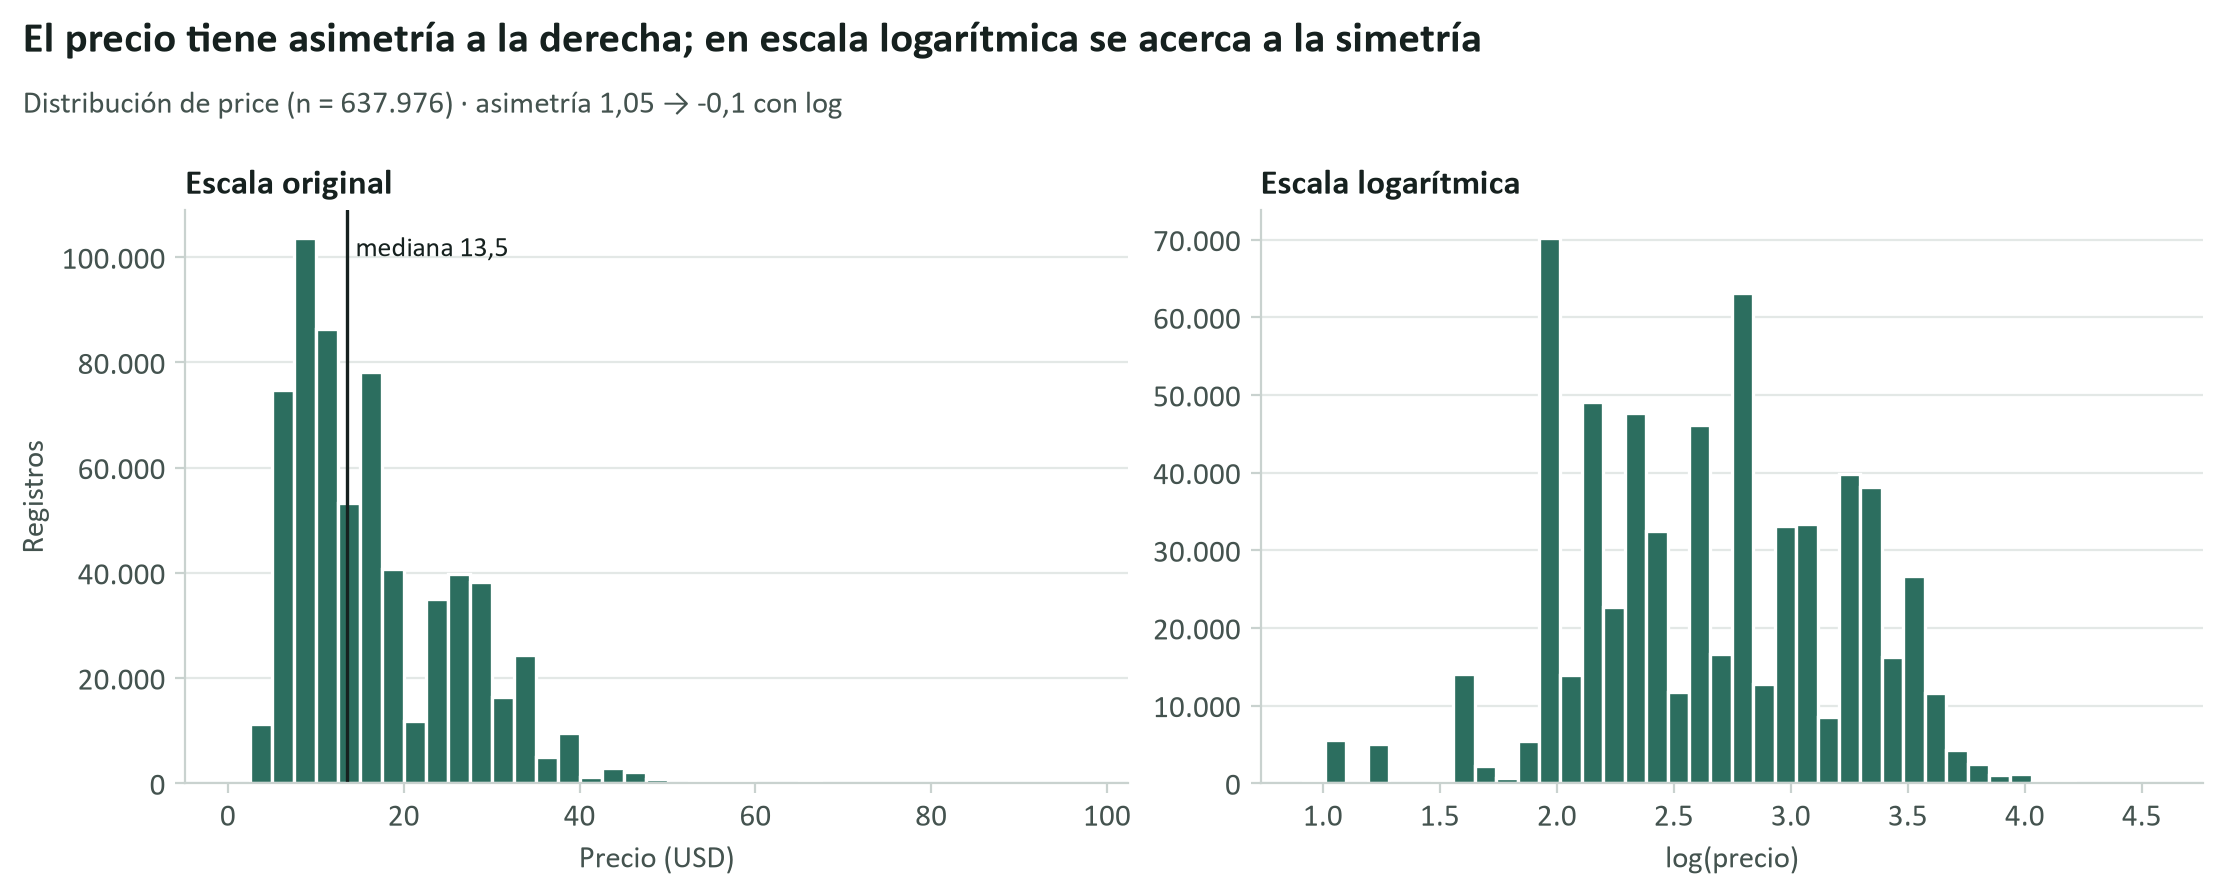

In [18]:
sesgo, sesgo_log = round(float(stats.skew(eda["price"])), 2), round(float(stats.skew(np.log(eda["price"]))), 2)
fig, (a1, a2) = figura(11, 4.4, 1, 2, titulo="El precio tiene asimetría a la derecha; en escala logarítmica se acerca a la simetría",
                       subtitulo=f"Distribución de price (n = {miles(len(eda))}) · asimetría " + f"{sesgo} → {sesgo_log} con log".replace(".", ","))
a1.hist(eda["price"], bins=np.arange(0, 100, 2.5), color=C["serie"], edgecolor="white", linewidth=1.2)
a1.set_xlabel("Precio (USD)"); a1.set_ylabel("Registros"); a1.set_title("Escala original")
a1.axvline(eda["price"].median(), color=C["tinta"], lw=1.2)
a1.text(eda["price"].median() + 1, a1.get_ylim()[1] * .92, f"mediana {eda['price'].median():.1f}".replace(".", ","), color=C["tinta"], fontsize=10)
a2.hist(np.log(eda["price"]), bins=40, color=C["serie"], edgecolor="white", linewidth=1.2)
a2.set_xlabel("log(precio)"); a2.set_title("Escala logarítmica")
for a in (a1, a2):
    a.yaxis.set_major_formatter(lambda v, p: miles(v)); a.grid(axis="x", visible=False)
guardar(fig, "13_precio_distribucion")

**14 · ¿Por qué `has_surge` solo con Lyft?** Porque Uber no informa el recargo: ninguna de sus cotizaciones tiene un multiplicador distinto de 1.

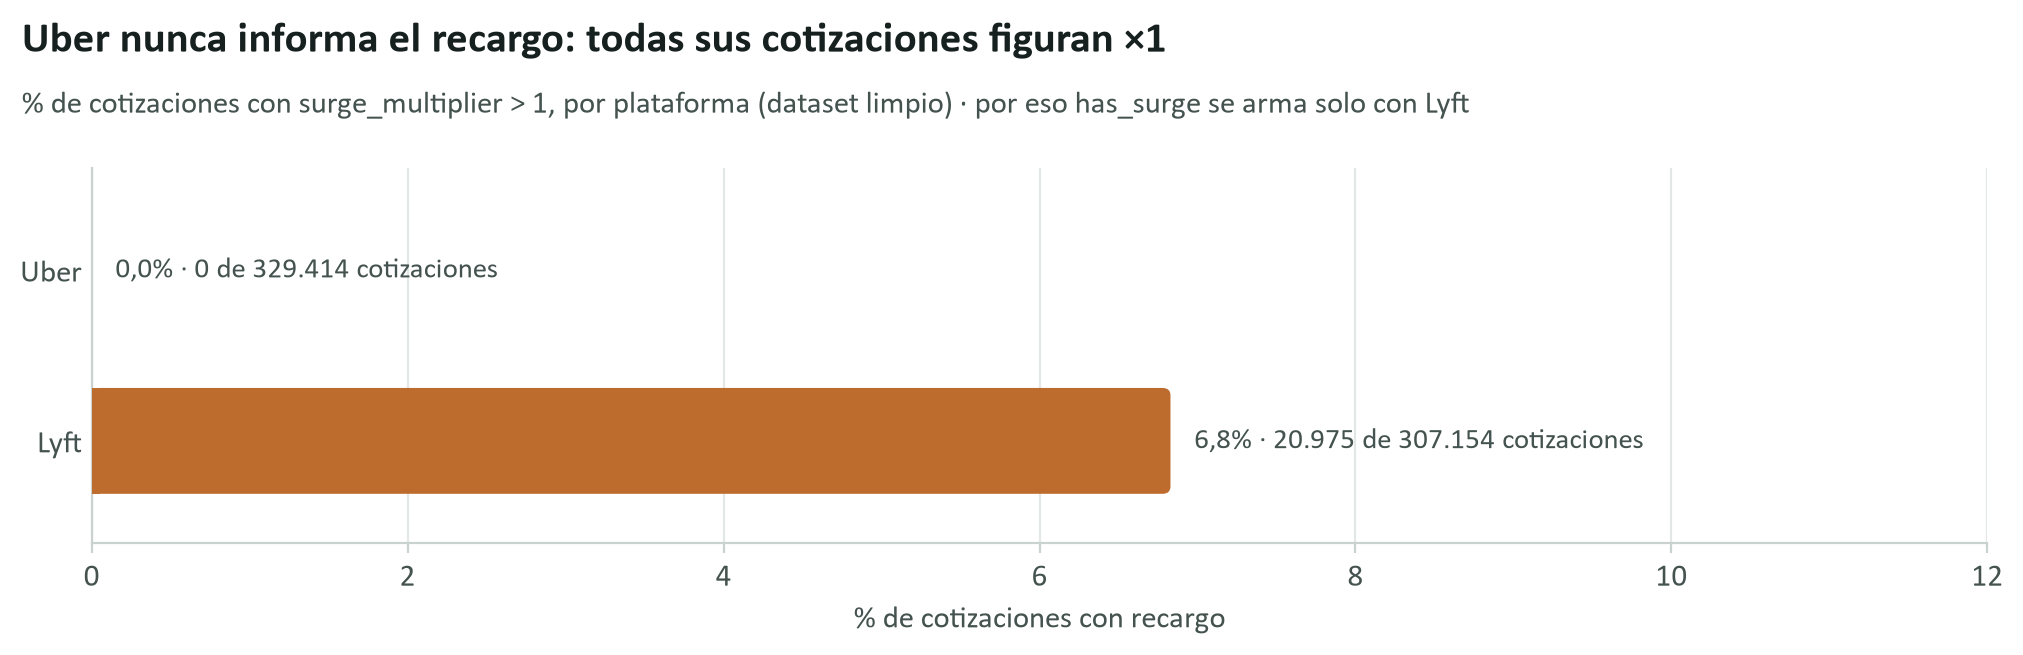

In [19]:
# Recargo por plataforma: Uber nunca lo informa
por_plat = (limpio.assign(con_recargo=limpio["surge_multiplier"] > 1)
            .groupby("cab_type")["con_recargo"].agg(["sum", "size"]).loc[["Uber", "Lyft"]])
por_plat["pct"] = 100 * por_plat["sum"] / por_plat["size"]
fig, ax = figura(10, 3.2, titulo="Uber nunca informa el recargo: todas sus cotizaciones figuran ×1",
                 subtitulo="% de cotizaciones con surge_multiplier > 1, por plataforma (dataset limpio) · por eso has_surge se arma solo con Lyft")
barras_h(ax, por_plat.index.tolist(), por_plat["pct"].values, [PLATAFORMA[p] for p in por_plat.index], xmax=12, etiquetar=False)
for i, (p, r) in enumerate(por_plat.iterrows()):
    ax.text(r["pct"] + 0.15, i, f"{pct(r['pct'], 1)} · {miles(r['sum'])} de {miles(r['size'])} cotizaciones",
            va="center", fontsize=10.5, color=C["tinta2"])
ax.set_xlabel("% de cotizaciones con recargo")
guardar(fig, "14_recargo_uber_vs_lyft")

**15 · ¿Por qué sin Lyft Shared?** Porque nunca tiene recargo (0 de 51.233): sumarlo solo agregaría ceros. El resto de los productos de Lyft tiene la misma tasa (8,19%): el recargo depende de la zona y el momento, no del producto.

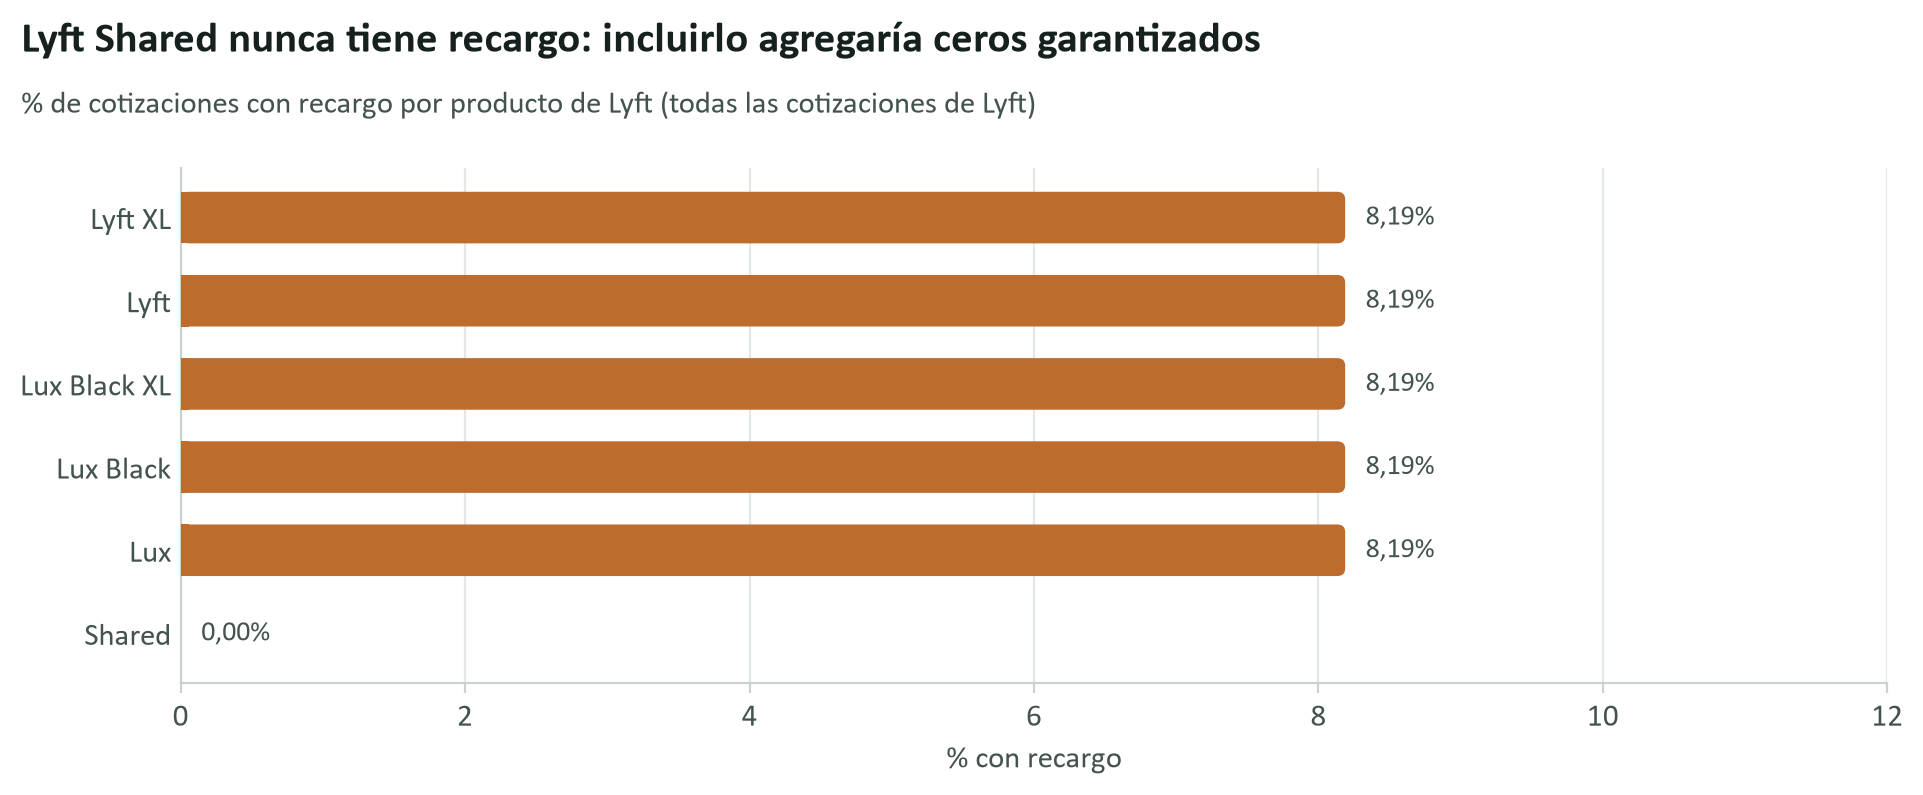

In [20]:
por_prod = lyft.groupby("name")["has_surge"].mean().mul(100).sort_values()
fig, ax = figura(9.5, 3.9, titulo="Lyft Shared nunca tiene recargo: incluirlo agregaría ceros garantizados",
                 subtitulo="% de cotizaciones con recargo por producto de Lyft (todas las cotizaciones de Lyft)")
barras_h(ax, por_prod.index.tolist()[::-1], por_prod.values[::-1], [C["gris"] if n == "Shared" else C["lyft"] for n in por_prod.index[::-1]],
         fmt=lambda v: pct(v, 2), xmax=12)
ax.set_xlabel("% con recargo")
guardar(fig, "15_recargo_por_producto")

**16 · ¿Uber o Lyft es más barato?** Depende del nivel: a igual distancia, Lyft es más barato en los económicos (Compartido: 18% menos) y más caro en los Black.

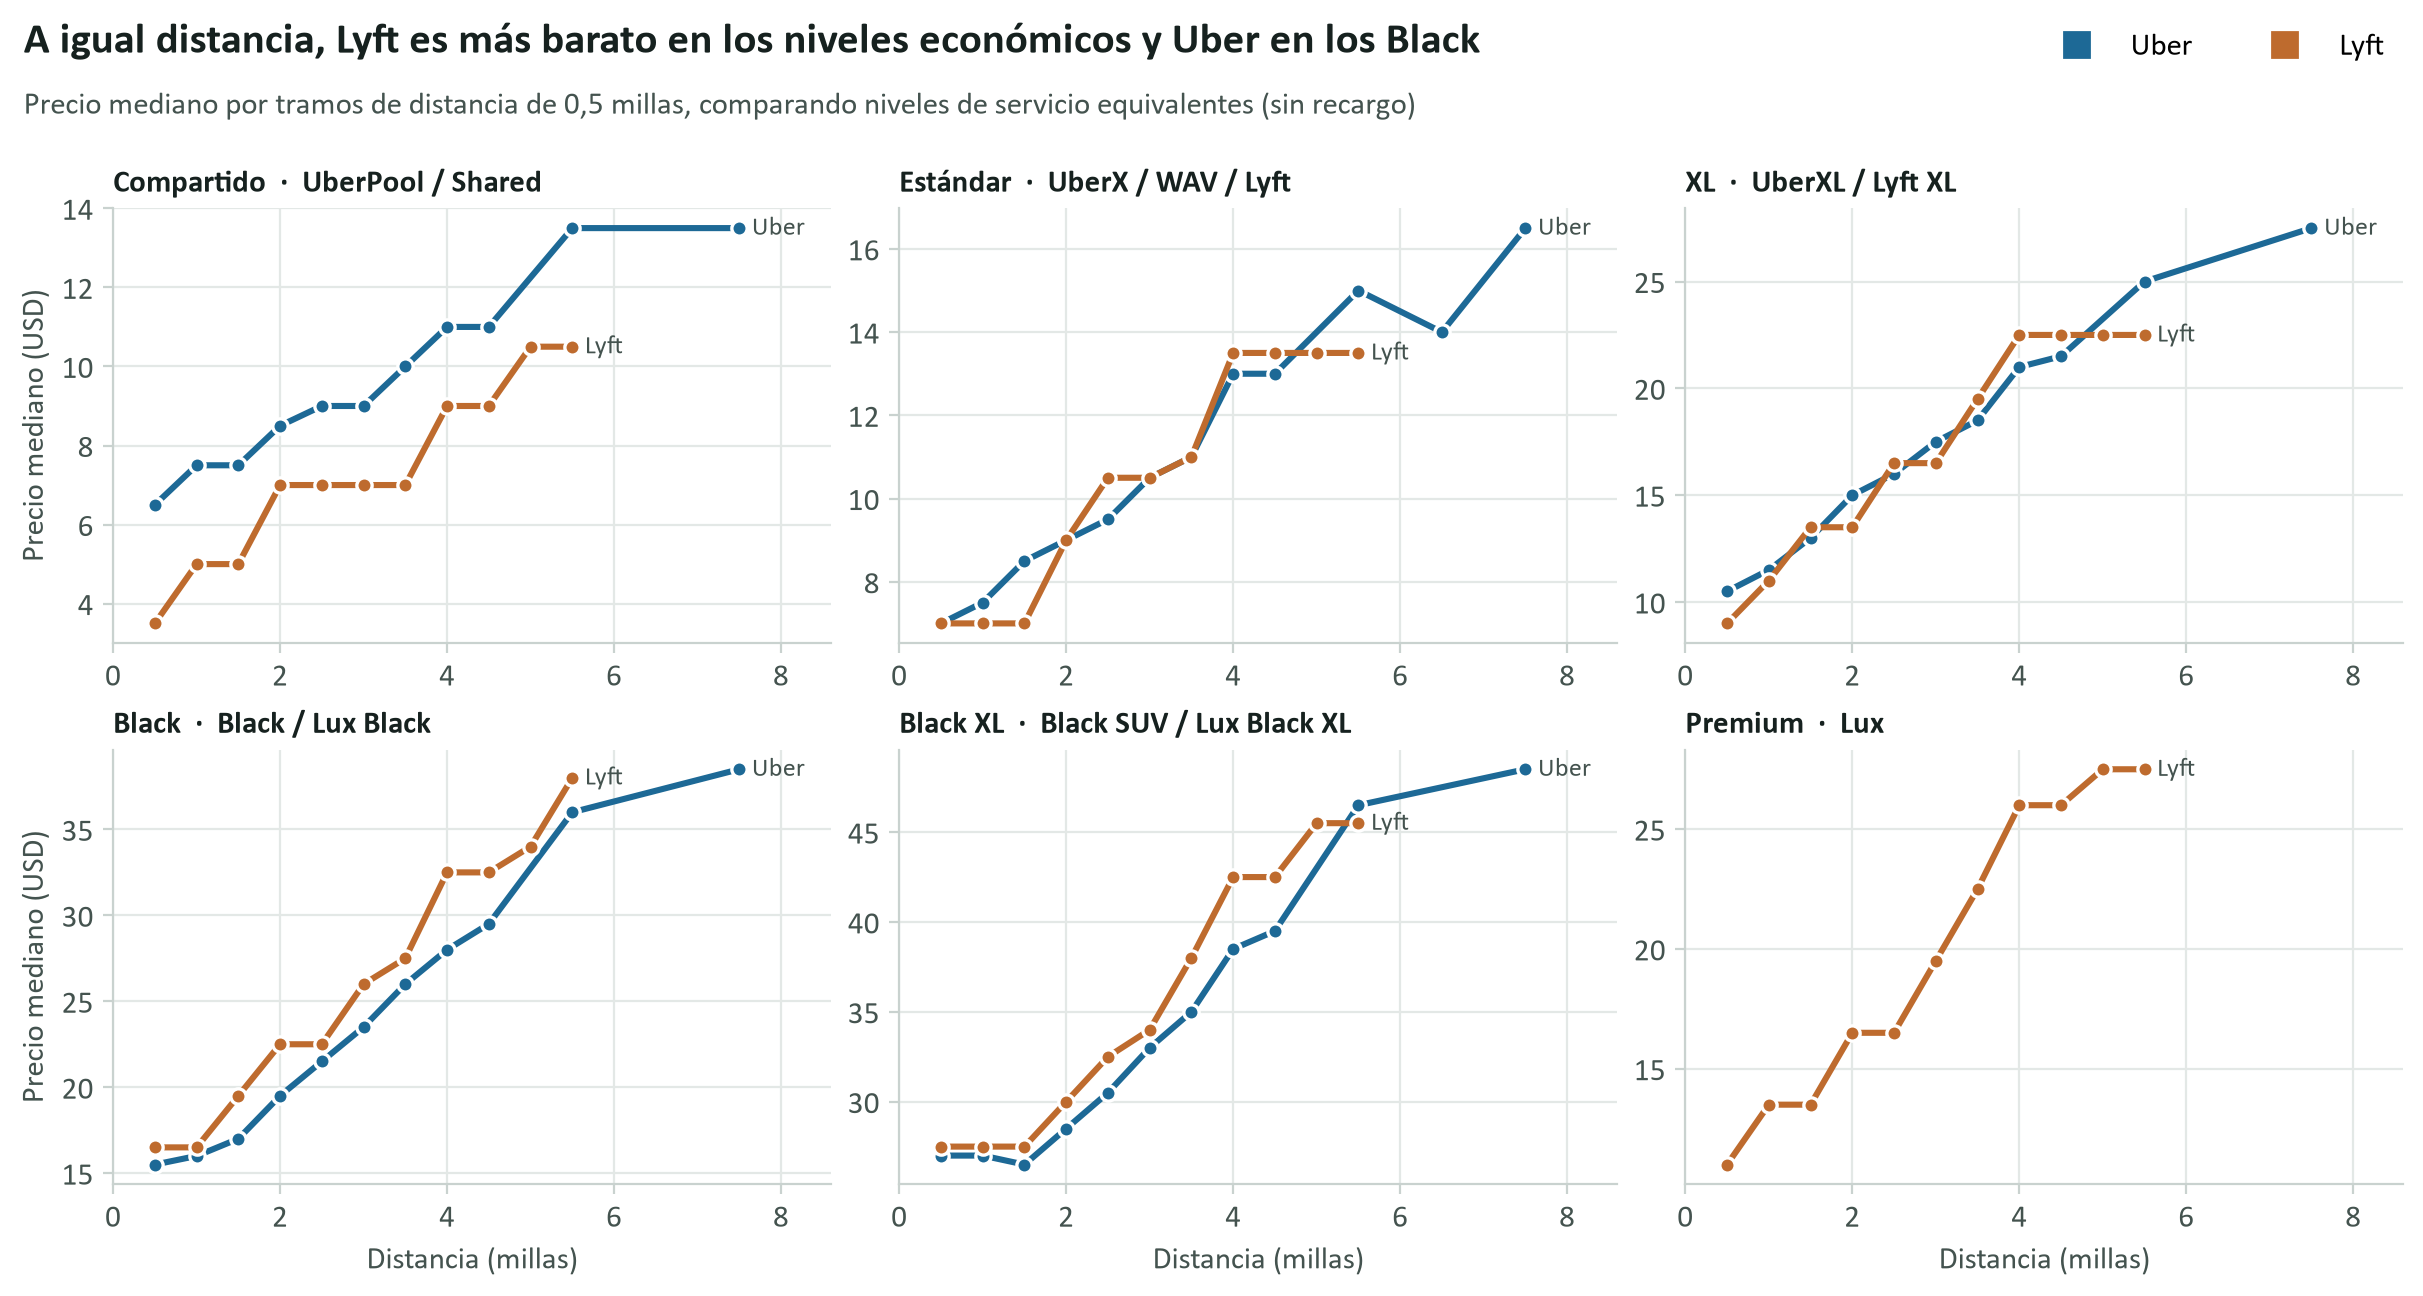

In [21]:
eda["dist_bin"] = (eda["distance"] / 0.5).round() * 0.5
base_comp = eda[eda["surge_multiplier"] == 1]
fig, axes = figura(12, 6.4, 2, 3, titulo="A igual distancia, Lyft es más barato en los niveles económicos y Uber en los Black",
                   subtitulo="Precio mediano por tramos de distancia de 0,5 millas, comparando niveles de servicio equivalentes (sin recargo)", sharey=False)
for ax, nivel in zip(axes.flat, ["Compartido", "Estándar", "XL", "Black", "Black XL", "Premium"]):
    sub = base_comp[base_comp["service_tier"] == nivel]
    for plat_ in ("Uber", "Lyft"):
        s = sub[sub["cab_type"] == plat_].groupby("dist_bin")["price"].agg(["median", "size"])
        s = s[s["size"] >= 200]
        if len(s):
            ax.plot(s.index, s["median"], color=PLATAFORMA[plat_], marker="o", markersize=5.5, markeredgecolor="white", markeredgewidth=1.2)
            ax.text(s.index[-1] + .15, s["median"].iloc[-1], plat_, color=C["tinta2"], fontsize=9.5, va="center")
    prods = " / ".join(sorted(sub["name"].unique(), key=lambda x: x not in ("UberX", "UberPool", "UberXL", "Black", "Black SUV", "WAV")))
    ax.set_title(f"{nivel}  ·  {prods}", fontsize=11); ax.set_xlim(0, 8.6)
for ax in axes[1]:
    ax.set_xlabel("Distancia (millas)")
for ax in axes[:, 0]:
    ax.set_ylabel("Precio mediano (USD)")
leyenda_plataformas(fig, loc="upper right", bbox_to_anchor=(1, 1.0), ncol=2)
guardar(fig, "16_precio_vs_distancia_por_nivel")

**17 · ¿El clima influye en el precio o en el recargo?** No se observa relación lineal: la correlación máxima es 0,0015 con el precio y 0,0069 con el recargo (la distancia, como referencia, tiene 0,345 con el precio). Con lluvia, 7,85% de recargo; sin lluvia, 8,28%.

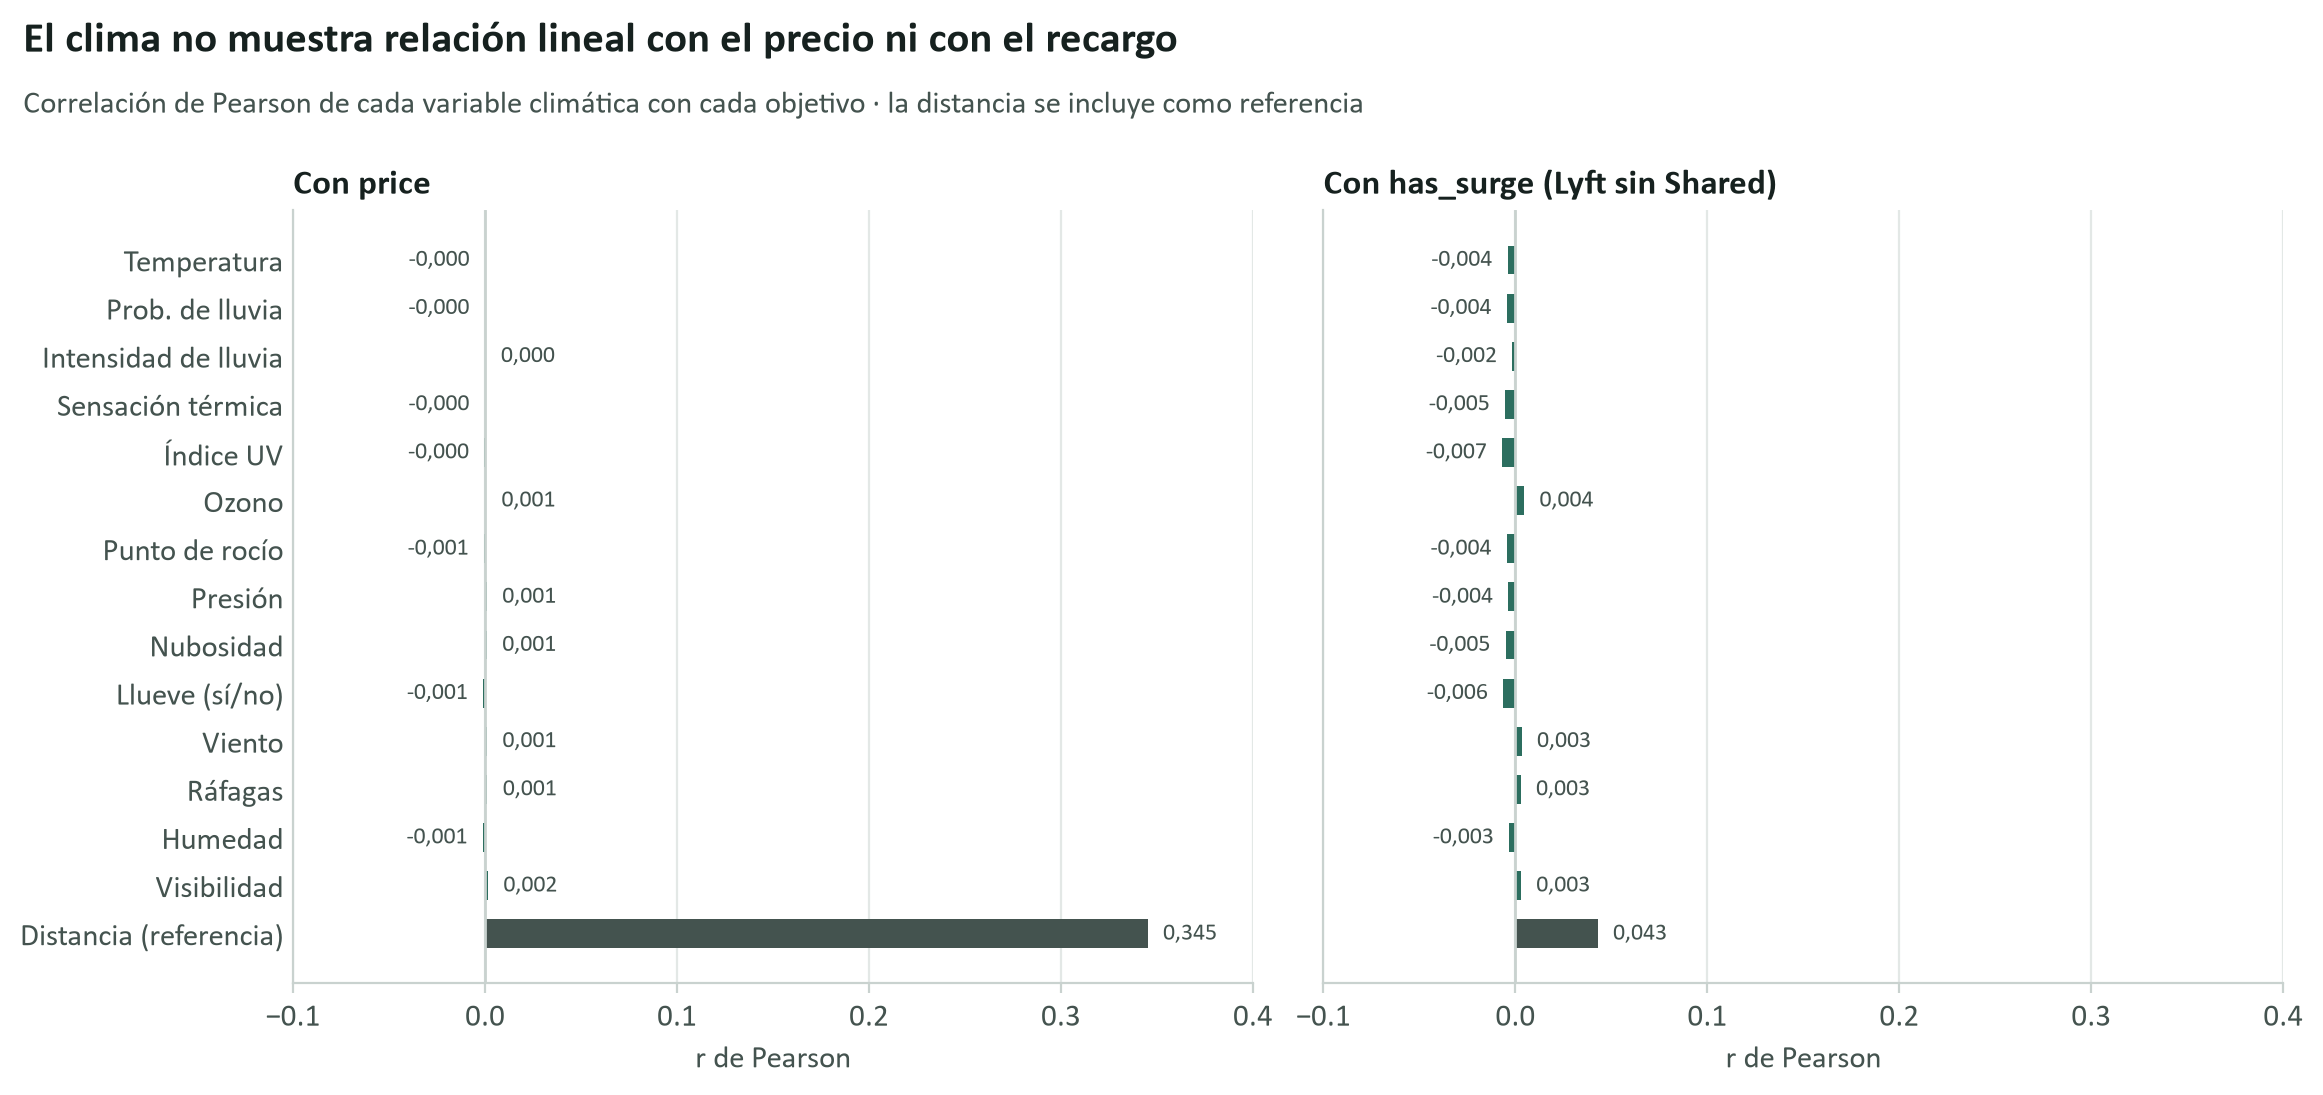

In [22]:
clima_vars = ["temperature", "apparentTemperature", "precipIntensity", "precipProbability", "humidity", "windSpeed",
              "windGust", "visibility", "cloudCover", "pressure", "dewPoint", "uvIndex", "ozone", "is_raining"]
corr_clima = pd.DataFrame({
    "r con price": eda[clima_vars + ["distance"]].corrwith(eda["price"]),
    "r con has_surge (Lyft sin Shared)": lyft_s[clima_vars + ["distance"]].corrwith(lyft_s["has_surge"].astype(float)),
}).round(4)
nombres_clima = {"temperature": "Temperatura", "apparentTemperature": "Sensación térmica", "precipIntensity": "Intensidad de lluvia",
                 "precipProbability": "Prob. de lluvia", "humidity": "Humedad", "windSpeed": "Viento", "windGust": "Ráfagas",
                 "visibility": "Visibilidad", "cloudCover": "Nubosidad", "pressure": "Presión", "dewPoint": "Punto de rocío",
                 "uvIndex": "Índice UV", "ozone": "Ozono", "is_raining": "Llueve (sí/no)", "distance": "Distancia (referencia)"}
fig, axes = figura(11.5, 5.4, 1, 2, titulo="El clima no muestra relación lineal con el precio ni con el recargo",
                   subtitulo="Correlación de Pearson de cada variable climática con cada objetivo · la distancia se incluye como referencia", sharey=True)
orden_c = corr_clima["r con price"].abs().sort_values(ascending=False).index.tolist()
for ax, colname, titulo_ in zip(axes, corr_clima.columns, ["Con price", "Con has_surge (Lyft sin Shared)"]):
    vals = corr_clima.loc[orden_c, colname]
    ax.barh(range(len(vals)), vals.values, color=[C["tinta2"] if i == "distance" else C["serie"] for i in orden_c], height=.6)
    ax.axvline(0, color=C["eje"], lw=1)
    ax.set_yticks(range(len(vals)), [nombres_clima[i] for i in orden_c]); ax.invert_yaxis()
    ax.set_xlim(-0.1, 0.4); ax.set_title(titulo_); ax.grid(axis="y", visible=False); ax.tick_params(axis="y", length=0)
    ax.set_xlabel("r de Pearson")
    for i, v in enumerate(vals.values):
        ax.text(v + (0.008 if v >= 0 else -0.008), i, f"{v:.3f}".replace(".", ","), va="center", ha="left" if v >= 0 else "right", fontsize=8.5, color=C["tinta2"])
guardar(fig, "17_clima_vs_objetivos")

**18 · ¿El recargo depende de la hora?** Poco: entre 7,0% (11 h) y 9,6% (8 h), alrededor del promedio de 8,19%.

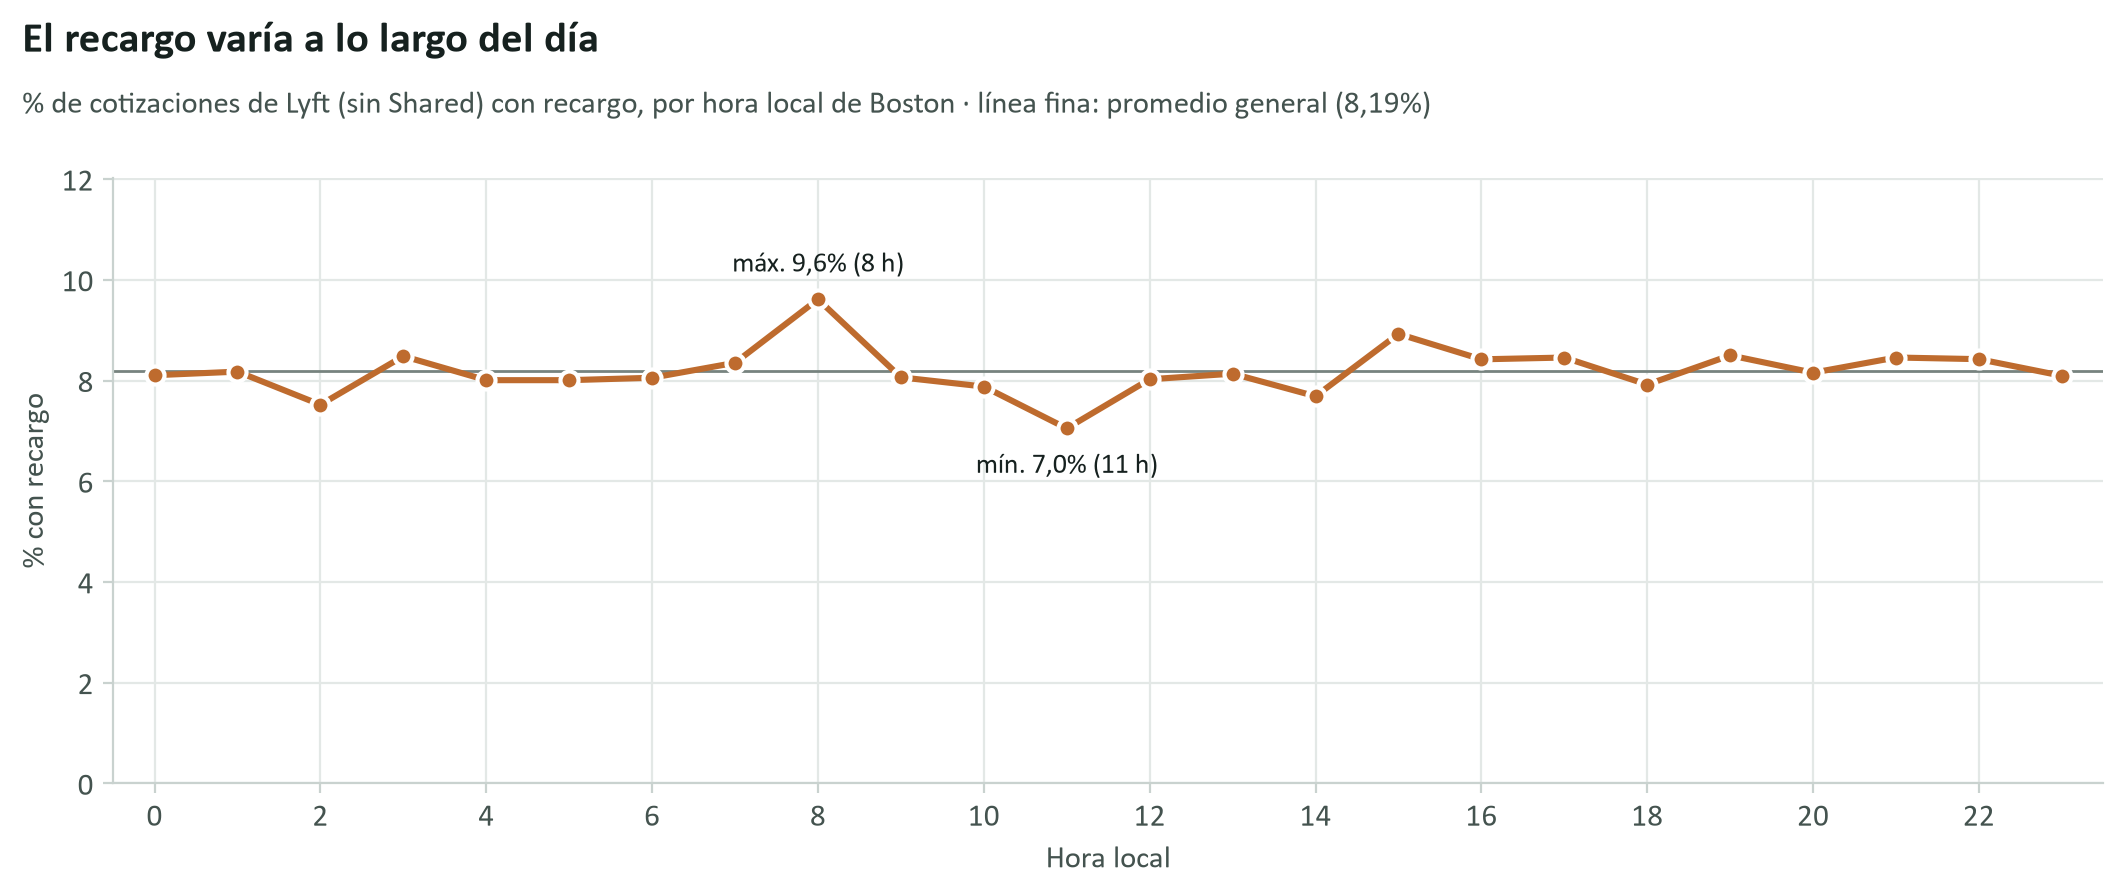

In [23]:
por_hora = lyft_s.groupby("hour_local")["has_surge"].mean().mul(100)
media_global = lyft_s["has_surge"].mean() * 100
hmax, hmin = por_hora.idxmax(), por_hora.idxmin()
fig, ax = figura(10.5, 4.4, titulo="El recargo varía a lo largo del día",
                 subtitulo=f"% de cotizaciones de Lyft (sin Shared) con recargo, por hora local de Boston · línea fina: promedio general ({pct(media_global, 2)})")
ax.plot(por_hora.index, por_hora.values, color=C["lyft"], marker="o", markersize=6.5, markeredgecolor="white", markeredgewidth=1.5, zorder=3)
ax.axhline(media_global, color=C["muted"], lw=1)
for h, txt in ((hmax, "máx."), (hmin, "mín.")):
    ax.annotate(f"{txt} {pct(por_hora[h], 1)} ({h} h)", (h, por_hora[h]), textcoords="offset points",
                xytext=(0, 10 if txt == "máx." else -16), ha="center", fontsize=10, color=C["tinta"])
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hora local"); ax.set_ylabel("% con recargo")
ax.set_ylim(0, por_hora.max() * 1.25); ax.set_xlim(-0.5, 23.5)
guardar(fig, "18_recargo_por_hora")

---
## Anexo · Preguntas probables en la defensa
**¿Por qué no completaron los precios de Taxi en lugar de borrarlos?**
Porque no hay ni un solo precio de Taxi (el 100% está vacío). Completarlos sería inventar la tarifa de un producto sin ninguna referencia: es un faltante estructural.

**¿Por qué no borraron los precios muy altos?**
Los detectamos con el rango intercuartílico (IQR) por producto. El 85% se explica por el recargo o por un viaje largo: son precios reales. Para que no distorsionen el modelo se trabajará con el logaritmo del precio.

**¿Por qué el informe dice 1.677 copias y 406 distancias, y acá se eliminan 1.060 y 348?**
El informe cuenta las detectadas en el archivo original. 617 copias y 58 distancias eran de Taxi, que ya se había sacado por no tener precio (ver la tabla resumen).

**¿Por qué sacaron el precio del dataset del recargo?**
Porque el precio ya incluye el recargo: el modelo lo "adivinaría" leyendo el precio. Eso es fuga de datos (*data leakage*) y da resultados engañosamente buenos.

**¿Y por qué sí dejan el multiplicador para predecir el precio?**
Porque la app lo muestra antes de pedir el viaje: no es información del futuro. Igual se entrenará con y sin esa variable para medir cuánto aporta.

**Si solo el 8% tiene recargo, ¿el modelo no va a decir siempre "no"?**
Ese es el riesgo: decir siempre "no" ya acierta el 92%. Por eso se medirá con PR-AUC, recall y F1, y se le dará más peso a la clase con recargo. Hay 20.975 casos positivos para aprender.

**¿Por qué el clima por hora y no por zona?**
Porque el archivo conserva un solo registro de clima por hora: la información por zona se perdió al armar el dataset original. Además, el clima casi no se relaciona con el precio ni con el recargo (gráfico 17).

**¿Por qué evaluar con días que el modelo no vio?**
Porque las cotizaciones de la misma ruta y el mismo minuto comparten el recargo (96% de los casos). Si se mezclan al azar, el modelo ve en el entrenamiento casi el mismo viaje que después evalúa, y las métricas salen infladas.